# Multi-object detection and classification in dashcam videos - Capstone Project

Done by **Thillaiambalam Arumugam**

## 1. Imports & Folder Setup

In [16]:
# core imports for the whole project
import random
import os, sys, time
import shutil
import collections
import statistics
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageDraw

import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as T
from torchvision import tv_tensors
import torchvision.models as tvm
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

torch.set_printoptions(linewidth=1000, profile="full")

In [17]:
# defining the folders path

HERE = r"C:\Users\thill\jupyter_folder\2 Capstone\driving_detection\Final_Submission"
IMG_DIR = os.path.join(HERE, "clean", "images")
LABEL_DIR = os.path.join(HERE, "clean", "labels")
OUT_DIR = os.path.join(HERE, 'final_dataset')

In [18]:
# quick sanity check of how many images and labels do we actually have
print('Total images:', len(os.listdir(IMG_DIR)), '\nTotal label files:', len(os.listdir(LABEL_DIR)))

Total images: 15000 
Total label files: 15000


## 2. Data Sanity Checking

In [19]:
# checking for empty label files
# checking file size to see if they hold anything

_sum = 0
for f in os.listdir(LABEL_DIR):
    if os.path.getsize(os.path.join(LABEL_DIR, f)) == 0:
        _sum += 1
print('Empty files count:', _sum)

# reason might be some images wont have anything worth detecting

Empty files count: 1761


In [20]:
# querying a label file

temp_label = random.choice(os.listdir(LABEL_DIR))
with open(os.path.join(LABEL_DIR, temp_label), 'r') as f:
    print(f.read())

1 0.9583333333333334 0.5666666666666667 0.08229166666666667 0.20166666666666666
1 0.11614583333333334 0.53875 0.053125 0.050833333333333335
1 0.03177083333333333 0.55 0.0625 0.11666666666666667
1 0.18072916666666666 0.5375 0.06979166666666667 0.075
6 0.19739583333333333 0.08833333333333333 0.036458333333333336 0.07
4 0.39114583333333336 0.15333333333333332 0.036458333333333336 0.07
1 0.4109375 0.5141666666666667 0.034375 0.045
1 0.4473958333333333 0.51 0.026041666666666668 0.04
1 0.5010416666666667 0.5166666666666667 0.027083333333333334 0.056666666666666664
1 0.5416666666666666 0.5508333333333333 0.09375 0.10166666666666667
4 0.5557291666666667 0.15 0.03229166666666667 0.11
4 0.5583333333333333 0.17 0.03125 0.09
1 0.6078125 0.5216666666666666 0.06354166666666666 0.07666666666666666
1 0.68125 0.5233333333333333 0.07291666666666667 0.08666666666666667
1 0.6739583333333333 0.5216666666666666 0.05625 0.09666666666666666
1 0.7338541666666667 0.53 0.078125 0.09
1 0.7239583333333334 0.5325 0

- each row is a label with - object_class, coordinate_X, coordinate_Y, width, height
- the coords, width and height are normalized values not actual values

## 3. Helper Functions

In [21]:
# reads a label file and returns them as a list of tuples with proper dtypes

def load_labels(label_file):
    boxes = []
    
    with open(label_file , "r") as f:
        raw_label = f.readlines()
        boxes = [tuple([int(x.split()[0])] + [float(y) for y in x.split()[1:]]) for x in raw_label]
    
    return boxes

In [22]:
# CLASS_COLORS for box outlines, and the real show_image helper used everywhere below
CLASS_COLORS = {0:'red', 1:'green', 2: 'yellow', 3:'blue', 4:'pink'}

def show_image(image, boxes = None, grid_size = 26, title = None):

    to_tensor = T.ToTensor() 
    image = to_tensor(image) # converting the image to a tensor for matplotlib display

    boxes = boxes
    
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy() # to_tensor gives channels-first (C,H,W); matplotlib/PIL both expect channels-last (H,W,C)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.imshow(image)

    H, W = image.shape[:2] # PIL uses H, W format when returning shape

    if boxes is not None:
        
        for cid, cx, cy, w, h in boxes:

            # normalizing/converting to actual image scale
            x = cx * W
            y = cy  * H

            box_w = w*W
            box_h = h*H

            # x and y are centers, matplotlib expects them to be top-left coord
            # so using basic graph knowledge converting them
            x = x - box_w / 2
            y = y - box_h / 2

            rect = patches.Rectangle((x,y), box_w, box_h, linewidth=2, edgecolor=CLASS_COLORS.get(cid, 'red'), facecolor='None')
            ax.add_patch(rect)

    # for showing grids on images
    ax.set_xticks(np.linspace(0, W, grid_size + 1))
    ax.set_yticks(np.linspace(0, H, grid_size + 1))
    ax.grid(color='yellow', linestyle='-', linewidth=0.5, alpha = 0.5)

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('')
        
    plt.show()

Image size: (1920, 1200)


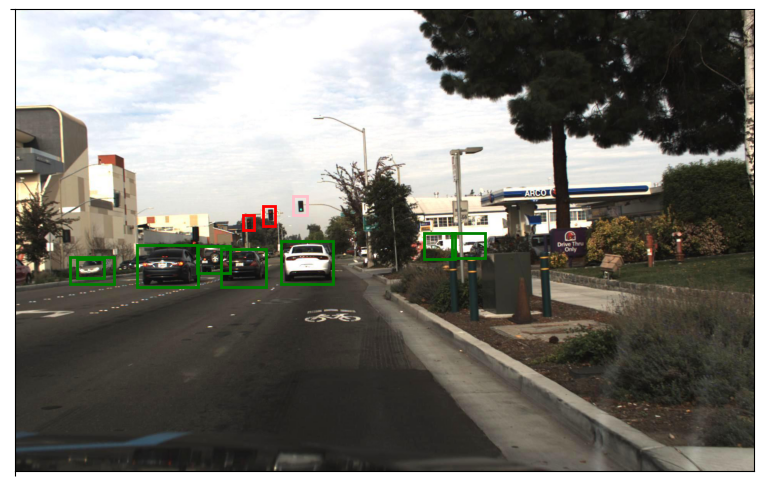

In [27]:
# getting and showing a random image

sample_path = os.path.join(IMG_DIR, random.choice(list(os.listdir(IMG_DIR))))
sample_label_path = sample_path.replace('images', 'labels').replace('jpg', 'txt')

img = Image.open(sample_path).convert('RGB')
W, H = img.size
print('Image size:', img.size) # not a perfect square 1920 x 1200

sample_label = load_labels(sample_label_path)

show_image(img, boxes = sample_label, grid_size = 0)

# 4. Label Handling

## 4.1. Class Imbalance Handling

In [28]:
# the raw dataset's 11 real classes, before any collapsing
OLD_CLASS_NAMES = ['biker', 'car', 'pedestrian', 'trafficLight', 'trafficLight-Green',
             'trafficLight-GreenLeft', 'trafficLight-Red', 'trafficLight-RedLeft',
             'trafficLight-Yellow', 'trafficLight-YellowLeft', 'truck']
OLD_ID = {i: name for i, name in enumerate(OLD_CLASS_NAMES)}
OLD_ID

{0: 'biker',
 1: 'car',
 2: 'pedestrian',
 3: 'trafficLight',
 4: 'trafficLight-Green',
 5: 'trafficLight-GreenLeft',
 6: 'trafficLight-Red',
 7: 'trafficLight-RedLeft',
 8: 'trafficLight-Yellow',
 9: 'trafficLight-YellowLeft',
 10: 'truck'}

In [29]:
# getting all files names
raw_label_files = sorted(f for f in os.listdir(LABEL_DIR) if f.endswith('txt'))
class_counter = collections.Counter() # to store the number of instance

#looping over each file to get the counts
for i, file in enumerate(raw_label_files):
    if (i + 1) % 500 == 0:
        print(f'\r{i+1}/15000 files processed', end='', flush=True)
        
    label_file_path = os.path.join(LABEL_DIR, file)
    label = load_labels(label_file_path)
    if len(label) == 0:
        continue
    label = np.array(label)
    class_counter.update(label[:,0])

class_counter = {int(k): int(v) for k, v in dict(class_counter).items()}
print()
print('\nProcessing done...') 
print(class_counter)

15000/15000 files processed

Processing done...
{10: 3623, 1: 64399, 2: 10806, 6: 6870, 7: 1751, 0: 1864, 3: 2568, 4: 5465, 5: 310, 9: 14, 8: 272}


In [32]:
# matching the cid to their actual class names

class_imbalance = [[k, OLD_CLASS_NAMES[k], v] for k, v in class_counter.items()]
class_imbalance_df = pd.DataFrame(class_imbalance, columns = ['class_id', 'class_name', 'count'])
class_imbalance_df.sort_values(by='class_id', ascending = True, inplace=True)
class_imbalance_df.reset_index(drop=True, inplace=True)
class_imbalance_df

,class_id,class_name,count
0,0,biker,1864
1,1,car,64399
2,2,pedestrian,10806
3,3,trafficLight,2568
4,4,trafficLight-Green,5465
5,5,trafficLight-GreenLeft,310
6,6,trafficLight-Red,6870
7,7,trafficLight-RedLeft,1751
8,8,trafficLight-Yellow,272
9,9,trafficLight-YellowLeft,14


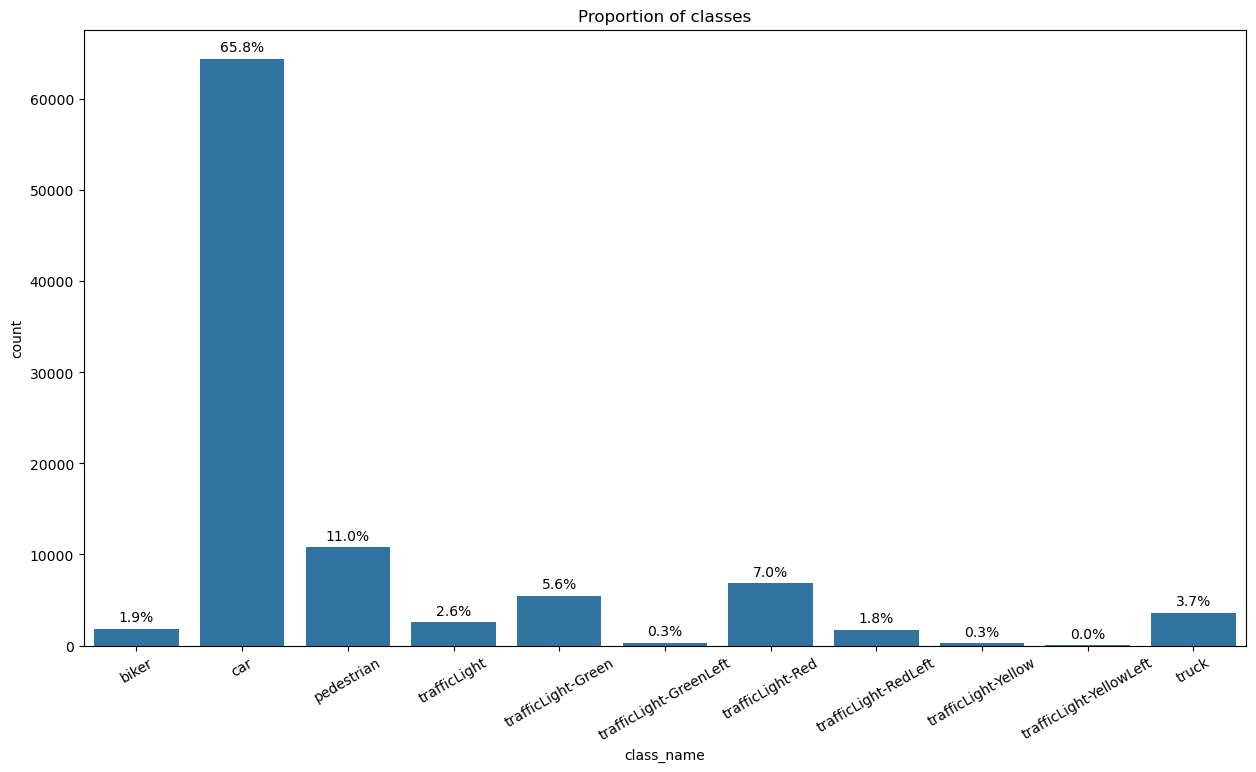

In [33]:
# plotting the class imbalance
total = class_imbalance_df['count'].sum()

plt.figure(figsize=(15,8))
ax = sns.barplot(data=class_imbalance_df, x='class_name', y='count')
ax.bar_label(ax.containers[0], labels=[f"{val/total:.1%}" for val in ax.containers[0].datavalues], padding=3)
ax.tick_params(axis='x', rotation=30)
plt.title('Proportion of classes')
plt.show()

## 4.1.1. Collapsing to 5 Classes

the raw dataset has 11 classes, but the traffic-light sub-states (Green/Red/Yellow/...) are really all just `trafficLight` for our purposes, collapsing them down to 5 real classes fixes a chunk of the imbalance for free, before any class-weighting even happens.

In [34]:
# collapsing them to five classes instead of 11

NEW_CLASS_NAMES = ['biker', 'car', 'pedestrian', 'truck', 'trafficLight']
NEW_ID = {name: i for i, name in enumerate(NEW_CLASS_NAMES)}
print('New collapsed class mapping:', NEW_ID)

COLLAPSE_MAP = {
    'biker': 'biker',
    'car': 'car',
    'pedestrian': 'pedestrian',
    'truck': 'truck',
    'trafficLight': 'trafficLight',
    'trafficLight-Green': 'trafficLight',
    'trafficLight-GreenLeft': 'trafficLight',
    'trafficLight-Red': 'trafficLight',
    'trafficLight-RedLeft': 'trafficLight',
    'trafficLight-Yellow': 'trafficLight',
    'trafficLight-YellowLeft': 'trafficLight',
}

New collapsed class mapping: {'biker': 0, 'car': 1, 'pedestrian': 2, 'truck': 3, 'trafficLight': 4}


In [35]:
# applying this collapse on the sample image

OLD_ID_TO_NEW_ID = {old_id: NEW_ID[COLLAPSE_MAP[old_name]] for old_id, old_name in enumerate(OLD_CLASS_NAMES)}
OLD_ID_TO_NEW_ID

{0: 0, 1: 1, 2: 2, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 3}

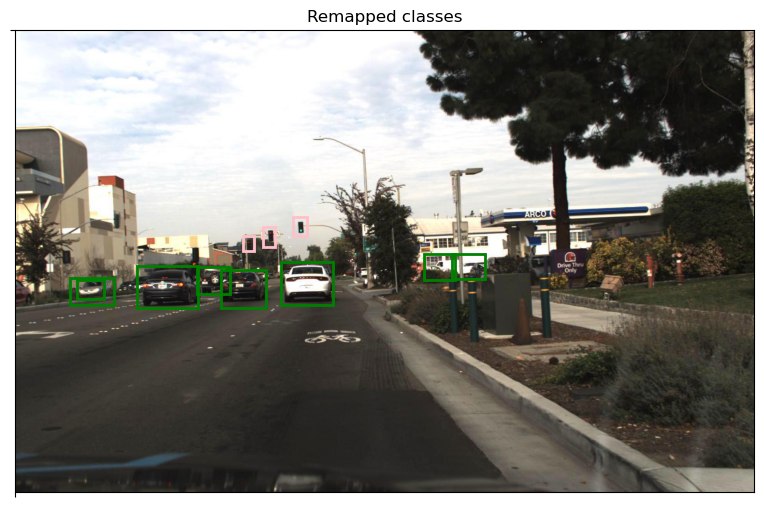

In [36]:
# the actual function that collapses an old class id down to its new 5-class id, applied to the sample image
def remap_classes(boxes):
    return [(OLD_ID_TO_NEW_ID[cid], xc, yc, w, h) for cid, xc, yc, w, h in boxes]

sample_label = remap_classes(sample_label)
show_image(img, boxes=sample_label, grid_size=0, title='Remapped classes')

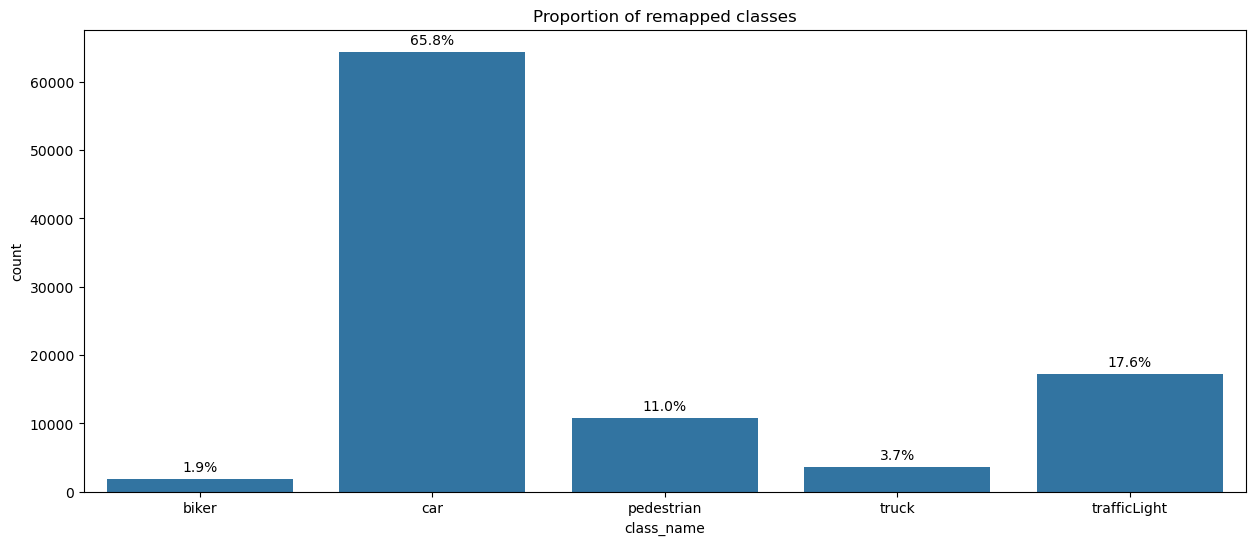

In [37]:
# checking the imbalance after remapping

class_imbalance_df['class_id'] = class_imbalance_df['class_id'].map(OLD_ID_TO_NEW_ID)
class_imbalance_df['class_name'] = class_imbalance_df['class_name'].map(COLLAPSE_MAP)
class_imbalance_df = class_imbalance_df.groupby(['class_id', 'class_name'], as_index=False)['count'].sum()

# plotting the class imbalance after remapping
total = class_imbalance_df['count'].sum()

plt.figure(figsize=(15,6))
ax = sns.barplot(data=class_imbalance_df, x='class_name', y='count')
ax.bar_label(ax.containers[0], labels=[f"{val/total:.1%}" for val in ax.containers[0].datavalues], padding=3)
plt.title('Proportion of remapped classes')
plt.show()

## 4.2. Removing Duplicate Boxes

some exports have the same object boxed twice (slightly different coords) after merging multiple source label files - if two boxes of the *same class* overlap almost completely (IoU > 0.9) they're almost certainly the same real object labeled twice, not two separate objects standing on top of each other. `box_iou` computes pairwise IoU between every box in an image (vectorized, no loop); `merge_duplicate_boxes` uses that to group and average out near-duplicates, via a small union-find over the `IoU > 0.9` pairs.

In [38]:
# removing duplicate boxes

# input normalized boxes of labels

def box_iou(labels):
    
    label_tensor = torch.tensor(labels, dtype=torch.float64)
    class_ids = label_tensor[:,0]
    boxes = label_tensor[:,1:]
    
    cx = boxes[:, 0]
    cy = boxes[:, 1]
    w = boxes[:, 2]
    h = boxes[:, 3]
    
    x0 = cx - w / 2
    y0 = cy - h / 2
    x1 = cx + w / 2
    y1 = cy + h /2
    
    area = (x1 - x0) * (y1 - y0)
    
    inter_x0 = torch.max(x0[:, None], x0[None, :])
    inter_y0 = torch.max(y0[:, None], y0[None, :])
    inter_x1 = torch.min(x1[:, None], x1[None, :])
    inter_y1 = torch.min(y1[:, None], y1[None, :])
    
    inter_w = (inter_x1 - inter_x0).clamp(min=0)
    inter_h = (inter_y1 - inter_y0).clamp(min=0)
    
    inter_w = (inter_x1 - inter_x0).clamp(min=0)
    inter_h = (inter_y1 - inter_y0).clamp(min=0)
    intersection = inter_w * inter_h
    
    union = area[:, None] + area[None, :] - intersection
    iou = intersection/union
    return class_ids, iou

In [39]:
# groups near-duplicate boxes (same class, IoU > threshold) and averages them into one
def merge_duplicate_boxes(labels, iou_thresh=0.9):
    class_ids, iou = box_iou(labels)  
    n = len(labels)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[rx] = ry

    same_class = class_ids[:, None] == class_ids[None, :]
    dup_mask = same_class & (iou > iou_thresh) & (~torch.eye(n, dtype=torch.bool))
    pairs = torch.triu(dup_mask, diagonal=1).nonzero()   # only upper triangle, no double-counting

    for i, j in pairs.tolist():
        union(i, j)

    groups = collections.defaultdict(list)
    for i in range(n):
        groups[find(i)].append(labels[i])

    merged = []
    n_removed = 0
    for group in groups.values():
        if len(group) == 1:
            merged.append(group[0])
        else:
            cid = group[0][0]
            xc = sum(b[1] for b in group) / len(group)
            yc = sum(b[2] for b in group) / len(group)
            w = sum(b[3] for b in group) / len(group)
            h = sum(b[4] for b in group) / len(group)
            merged.append((cid, xc, yc, w, h))
            n_removed += len(group) - 1

    return merged, n_removed

### 4.2.1 Example - before vs. after, on the sample image

quick check on the same sample image from earlier: how many duplicate pairs does it actually have before merging, and what does the label set look like after.

In [40]:
# how many duplicate box pairs does the sample image have, before merging
class_ids, iou = box_iou(sample_label)
print('Pairwise IOU:')
print(iou)

duplicates = (class_ids[:, None] == class_ids[None, :]) & (iou > 0.5) & (~torch.eye(len(class_ids), dtype=torch.bool))
upper = torch.triu(duplicates, diagonal=1)   # zero out everything on/below the diagonal
duplicates_count = upper.sum().item()
print('\nDuplicates present in the dataset:', duplicates_count)

Pairwise IOU:
tensor([[1.0000, 0.4191, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4191, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000, 0.0120, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0120, 1.0000, 0.0839, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0839, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0499],
      

In [41]:
# actually merging the sample image's duplicate boxes now
sample_label, n_merged = merge_duplicate_boxes(sample_label)

Merged 0 duplicate box(es)


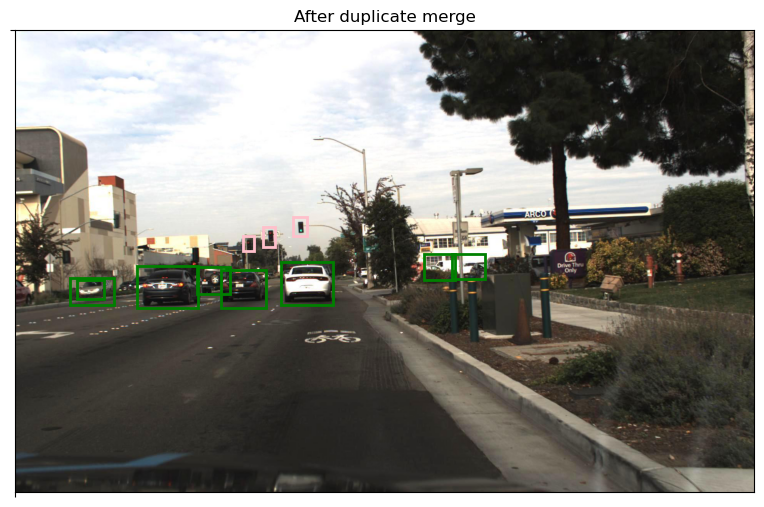

In [42]:
# showing the result after the merge
print(f'Merged {n_merged} duplicate box(es)')
show_image(img, boxes=sample_label, grid_size=0, title='After duplicate merge')

### 4.2.2 Running this across the whole dataset

In [43]:
# running on files and computing iou and seeing the number of duplicates

raw_label_files = sorted(f for f in os.listdir(LABEL_DIR) if f.endswith('txt'))
total_duplicates = 0

for i, file in enumerate(raw_label_files):
    label_file_path = os.path.join(LABEL_DIR, file)
    with open(label_file_path, "r") as f:
        lines = [l.strip() for l in f if l.strip()]
    raw_boxes = [tuple([int(x.split()[0])] + [float(y) for y in x.split()[1:]]) for x in lines]
    remapped = remap_classes(raw_boxes)
    if len(remapped) < 2:
        continue
    _, n_removed = merge_duplicate_boxes(remapped)
    total_duplicates += n_removed

    if (i + 1) % 500 == 0:
        print(f'\r{i+1}/15000 files processed | Total duplicates: {total_duplicates}', end='', flush=True)

print()

15000/15000 files processed | Total duplicates: 324


# 5. Data pre-processing

## 5.1. Time-Aware Train/Valid/Test Split

these images come from continuous dashcam recording, not random single images. So splitting randomly at the image level would let to data leakage, quietly inflating val/test scores. instead we are grouping frames into time-contiguous blocks with each block not exceeding 60s, and then we shuffle the whole blocks. Then assign blocks to train/valid/test.

In [44]:
# checking the real time gap between consecutive images, to see if this is continuous video
all_bases = [os.path.splitext(f)[0] for f in os.listdir(IMG_DIR)]
bases = sorted(int(b) for b in all_bases)   # numeric sort
gaps_seconds = [(bases[i] - bases[i-1]) / 1e9 for i in range(1, len(bases))]

print('Median gap diff between two images:', statistics.median(gaps_seconds))
print('Average FPS between images:', round(1/statistics.median(gaps_seconds),2), 'fps')

Median gap diff between two images: 0.571372069
Average FPS between images: 1.75 fps


In [45]:
# same idea as above, but also cap each block at block_seconds so no single block gets too large
block_seconds = 60
gap_seconds = 60

blocks = []
current = [bases[0]]
block_start_ts = bases[0]

for i in range(1, len(bases)):
    ts = bases[i]
    prev_ts = bases[i - 1]
    gap = (ts - prev_ts) / 1e9
    elapsed = (ts - block_start_ts) / 1e9

    if gap > gap_seconds or elapsed > block_seconds:
        blocks.append(current)
        current = []
        block_start_ts = ts

    current.append(ts)

blocks.append(current)

print('Total blocks created:', len(blocks))

Total blocks created: 146


In [46]:
# shuffling whole blocks (not individual frames) and assigning them to train/valid/test
random.seed(42)  
shuffled = blocks[:]
random.shuffle(shuffled)

total_frames = sum(len(b) for b in blocks)
target_train = 0.8 * total_frames
target_val = 0.1 * total_frames

split = {"train": [], "valid": [], "test": []}
running = {"train": 0, "valid": 0, "test": 0}

for block in shuffled:
    if running["train"] < target_train:
        split["train"].extend(block)
        running["train"] += len(block)
    elif running["valid"] < target_val:
        split["valid"].extend(block)
        running["valid"] += len(block)
    else:
        split["test"].extend(block)
        running["test"] += len(block)

for name, frames in split.items():
    print(name, len(frames), f"{100*len(frames)/total_frames:.1f}%")

train 12055 80.4%
valid 1572 10.5%
test 1373 9.2%


In [ ]:
# creating the train-test-split and creating folders for that

OUT_DIR = os.path.join(HERE, 'final_dataset')
print_counter = 0

def process_and_rewrite(base, out_img_dir, out_lbl_dir):
    raw_boxes = load_labels(os.path.join(LABEL_DIR, base + '.txt'))
    remapped = remap_classes(raw_boxes)

    if len(remapped) >= 2:
        merged, n_removed = merge_duplicate_boxes(remapped)
    else:
        merged = remapped

    shutil.copy(os.path.join(IMG_DIR, base + '.jpg'), os.path.join(out_img_dir, base + '.jpg'))
    
    with open(os.path.join(out_lbl_dir, base + ".txt"), "w") as f:
        for cid, xc, yc, w, h in merged:
            f.write(f"{cid} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

for split_name, timestamps in split.items():
    print_counter = 0
    img_out = os.path.join(OUT_DIR, split_name, "images")
    lbl_out = os.path.join(OUT_DIR, split_name, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    total = len(timestamps)

    for ts in timestamps:
        print_counter += 1
        process_and_rewrite(str(ts), img_out, lbl_out)
        print(f'\r{split_name}: {print_counter}/{total} processed', end='', flush=True)

    print()

In [48]:
# checking all folders
for split_name in ["train", "valid", "test"]:
    n_images = len(os.listdir(os.path.join(OUT_DIR, split_name, "images")))
    n_labels = len(os.listdir(os.path.join(OUT_DIR, split_name, "labels")))
    print(split_name, n_images, n_labels)

train 12055 12055
valid 1572 1572
test 1373 1373


## 5.2. Augmentation Pipeline

The whole pipeline flow from start to finish is: raw image -> **random scale+translate** (training only) -> **letterbox** (always) -> resize to 416x416 (always) -> **flip+color jitter** (training only) -> `build_target_grid` -> normalize. 

### 5.2.1. Random scale + translate

zooms in/out a little and anything cropped more than 60% out of frame gets dropped entirely rather than kept

In [49]:
# scaling and then pasting an image on the same original sized canvas
# input - image, normalized remapped, deduped boxes
# output - random scaled translated canvas, altered boxes (normalized)

def random_translate(img, boxes):
    random_translated_boxes = []
    
    W, H = img.size
    
    scale = random.uniform(0.8, 1.2)
    new_W, new_H = int(W*scale), int(H*scale)
    scaled_image = img.resize((new_W, new_H), Image.BILINEAR)

    max_dx, max_dy = int(W * 0.1), int(H * 0.1)
    offset_x = (W - new_W) // 2 + random.randint(-max_dx, max_dx)
    offset_y = (H - new_H) // 2 + random.randint(-max_dy, max_dy)

    canvas = Image.new('RGB', (W,H), (114,114,114))
    canvas.paste(scaled_image, (offset_x, offset_y))

    if len(boxes) == 0:
        return canvas, []
         
    boxes = torch.tensor(boxes, dtype=torch.float64)

    cid = boxes[:,0]
    cx = boxes[:,1]
    cy = boxes[:,2]
    w = boxes[:,3]
    h = boxes[:,4]

    px_cx = (cx * W * scale) + offset_x
    px_cy = (cy * H * scale) + offset_y
    px_w = w * W * scale
    px_h = h * H * scale
    
    # converting to coords 
    actual_x0 = px_cx - px_w / 2
    actual_y0 = px_cy - px_h / 2
    actual_x1 = px_cx + px_w / 2
    actual_y1 = px_cy + px_h / 2
    
    actual_area = (actual_x1 - actual_x0) * (actual_y1 - actual_y0)
    
    px_x0 = actual_x0.clamp(min=0)
    px_y0 = actual_y0.clamp(min=0)
    px_x1 = actual_x1.clamp(max=W)
    px_y1 = actual_y1.clamp(max=H)
    
    visible_area = (px_x1 - px_x0) * (px_y1 - px_y0)
    
    # converting coords back to centers, w and h
    new_cx = (px_x0 + px_x1) / 2 / W
    new_cy = (px_y0 + px_y1) / 2 / H
    new_w = (px_x1 - px_x0) / W
    new_h = (px_y1 - px_y0) / H
    
    
    mask = (visible_area/actual_area) > 0.4
    
    filtered_labels = torch.stack([cid, new_cx, new_cy, new_w, new_h], dim = 1)
    filtered_labels = filtered_labels[mask]
    
    # list(map(tuple,filtered_labels.tolist())) #this to list converts everything to a plain python float including the classes, which is wrong
    random_translated_boxes = [(int(c), cx_, cy_, w_, h_) for c, cx_, cy_, w_, h_ in filtered_labels.tolist()]
    
    return canvas, random_translated_boxes

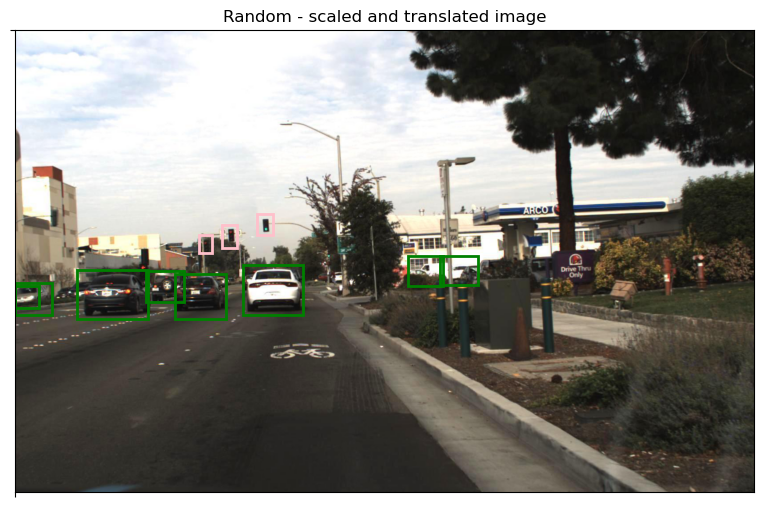

In [51]:
# trying random_translate on the sample image
temp0, temp1 = random_translate(img, sample_label)
show_image(temp0, temp1, title='Random - scaled and translated image', grid_size=0)

### 5.2.2. Letterboxing

images come in different aspect ratios. So plain resizing straight to a square would stretch or distort them. Thus we add padding to make the image square, and then resize to 416x416 to make sure no distortion happens

In [52]:
# letterboxing to get perfect squres without any distortion or anythign to orginal image

PAD_COLOR = (114, 114, 114) # grey

def letterbox(img, boxes):
    letterboxed_labels = []
    
    W, H = img.size
    
    pad_size = max(W, H) #getting the bigger side
    pad_top = (pad_size - H) // 2
    pad_left = (pad_size - W) // 2

    # creating a new squared canvas
    canvas = Image.new('RGB', (pad_size, pad_size), PAD_COLOR)

    # pasting the actual image onto the canvas
    canvas.paste(img, (pad_left, pad_top))

    if len(boxes) == 0:
        return canvas, []
    
    boxes = torch.tensor(boxes, dtype=torch.float64)

    cid = boxes[:,0]
    cx = boxes[:,1]
    cy = boxes[:,2]
    w = boxes[:,3]
    h = boxes[:,4]

    boxes[:, 1] = (boxes[:, 1] * W + pad_left) / pad_size
    boxes[:, 2] = (boxes[:, 2] * H + pad_top) / pad_size
    boxes[:, 3] = (boxes[:, 3] * W) / pad_size
    boxes[:, 4] = (boxes[:, 4] * H) / pad_size
    
    letterboxed_labels = [(int(c), cx_, cy_, w_, h_) for c, cx_, cy_, w_, h_ in boxes.tolist()]

    return canvas, letterboxed_labels

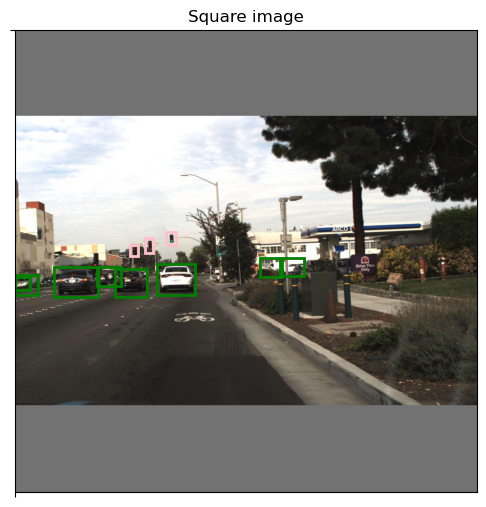

In [53]:
# showing letterboxed with old labels

canvas, labels = letterbox(temp0, temp1)
show_image(canvas, boxes=labels, grid_size=0, title='Square image')

### 5.2.3. Flip + color jitter

In [54]:
# the flip+jitter transform, and the real NORMALIZE pipeline used everywhere
flip_jitter = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
])


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

NORMALIZE = T.Compose([
    T.ToImage(),                              # PIL -> tensor, still 0-255, still uint8
    T.ToDtype(torch.float32, scale=True),      # convert to float32 AND rescale 0-255 -> 0-1
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def apply_flip_jitter(canvas, boxes):
    if len(boxes) == 0:
        return flip_jitter(canvas), []

    cids = [b[0] for b in boxes]
    geo = torch.tensor([[b[1]*416, b[2]*416, b[3]*416, b[4]*416] for b in boxes], dtype=torch.float32)

    tv_boxes = tv_tensors.BoundingBoxes(geo, format='CXCYWH', canvas_size=(416, 416))
    out_canvas, out_boxes = flip_jitter(canvas, tv_boxes)

    result = [(cid, x[0]/416, x[1]/416, x[2]/416, x[3]/416)
              for cid, x in zip(cids, out_boxes.tolist())]
    return out_canvas, result

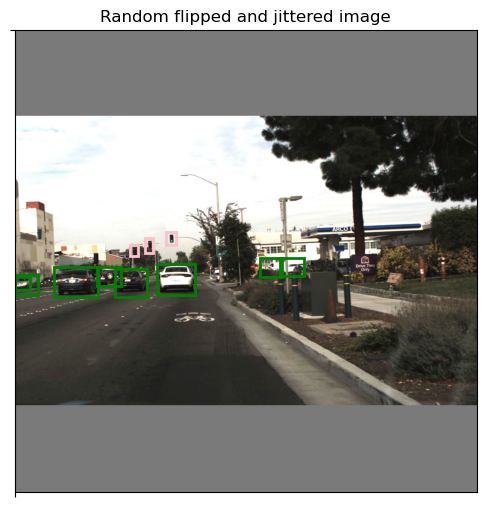

In [55]:
# trying flip+jitter on the same (already letterboxed) sample image
hehe, haha = apply_flip_jitter(canvas, labels)
show_image(hehe, haha, grid_size=0, title='Random flipped and jittered image')

# 6. Building the Grid Target

We have decide a grid size of 26x26. So any image will have 26x26 cells. Each cell will have 4 slots. Inside each slot we will have 10 values - objectness, cx, cy, w, h and 5 one hot encoded values. Thus we can say that every image gets encoded into a fixed `(26,26,4,10)` tensor. So this is the target shape our model will towards. Here the cx and cy are stored as cell-relative (like offset within that cell)

In [56]:
# code to convert the labels to a tensor of 26x26x4x10
def build_target_grid(boxes):         
    n_dropped = 0
    slots_used = {}
    target = torch.zeros(26, 26, 4, 10)
    ordered = sorted(boxes, key=lambda b: b[3]*b[4],reverse=True)
    for cid, cx, cy, w, h in ordered:
        row = min(int(cy * 26),25)
        col = min(int(cx * 26),25)
        key = (row, col)
        slots_used[key] = slots_used.get(key, 0) + 1
        used = slots_used.get(key, 0)
        slot = used - 1
        if slot >= 4:
            n_dropped += 1
        else:
            target[row, col, slot, 0] = 1.0
            target[row, col, slot, 1] = (cx*26) - col
            target[row, col, slot, 2] = (cy*26) - row
            target[row, col, slot, 3] = w
            target[row, col, slot, 4] = h
            target[row, col, slot, 5 + cid] = 1.0
    assert sum(list(slots_used.values())) == len(ordered)
    return target, n_dropped

In [57]:
# quick shape check
(build_target_grid(labels)[0]).shape

torch.Size([26, 26, 4, 10])

## 7. The Dataset Class

Here the dataset class wraps every piece above into one real torch Dataset module in the order we want.

load -> random_translate (only for train) -> letterbox -> resize to 416 -> flip+jitter (only for train) -> build_target_grid -> normalize

In [58]:
# defining the datset to be used for train/val/test
class DrivingDetectionDataset(Dataset):
    def __init__(self, split, augment=False, need_boxes = False):
        assert split in ("train", "valid", "test")
        self.split = split
        self.augment = augment
        self.img_dir = os.path.join(OUT_DIR, self.split, "images")
        self.label_dir = os.path.join(OUT_DIR, self.split, "labels")
        self.bases = sorted(f[:-4] for f in os.listdir(self.img_dir))
        self.need_boxes = need_boxes
        
    def __len__(self):
        return len(self.bases)

    def __getitem__(self, idx):
        base = self.bases[idx]
        img = Image.open(os.path.join(self.img_dir, base + '.jpg')).convert("RGB")
        boxes = load_labels(os.path.join(self.label_dir, base + '.txt'))

        if self.augment:
            img, boxes = random_translate(img, boxes)

        canvas, boxes = letterbox(img, boxes)

        canvas = canvas.resize((416, 416), Image.BILINEAR)

        if self.augment:
            canvas, boxes = apply_flip_jitter(canvas, boxes)

        target, _ = build_target_grid(boxes)
        img_tensor = NORMALIZE(canvas)

        if self.need_boxes:
            return img_tensor, target, boxes
        else:
            return img_tensor, target

In [59]:
# reverses NORMALIZE, for visual display purposes
def unnormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)

    img = img_tensor * std_t + mean_t   # reverse the normalize: undo divide by std, undo subtraction mean
    img = img.clamp(0, 1)               

    img = (img * 255).byte()            # back to 0-255
    img = img.permute(1, 2, 0).numpy()  # (C,H,W) to (H,W,C), since PIL/display expects channels last
    return Image.fromarray(img)

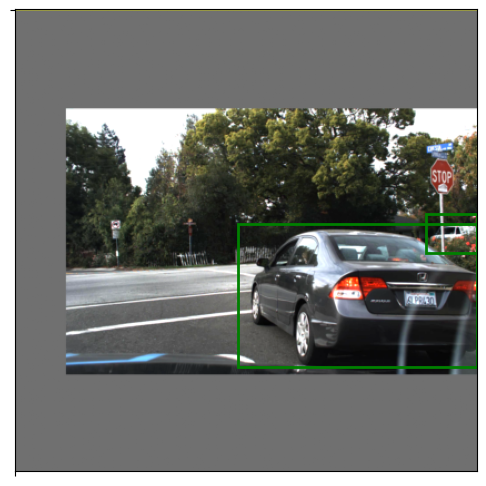

In [61]:
# pulling one random real sample straight out of the Dataset, augmentations included
dataset = DrivingDetectionDataset('train', augment=True, need_boxes = True)

# getting a random image
idx = random.randint(0, len(dataset)-1)
img_tensor, target, boxes = dataset[idx]
show_image(unnormalize(img_tensor), boxes = boxes, grid_size=0)

## 7.1 DataLoader

In [62]:
# make capstone_python_files importable, so num_workers>0 can actually work (see note above)
sys.path.insert(0, r"C:\Users\thill\jupyter_folder\2 Capstone\driving_detection\Final_Submission\capstone_python_files")

from dataset import DrivingDetectionDataset

In [63]:
%%time

# wrapping the train datset in dataloader
train_loader = DataLoader(DrivingDetectionDataset("train", augment=True, need_boxes=False),
                           batch_size=32, shuffle=True, num_workers=6,
                           pin_memory=True, persistent_workers=True)

CPU times: total: 31.2 ms
Wall time: 24.2 ms


In [64]:
%%time

# same for the validation set
valid_loader = DataLoader(DrivingDetectionDataset("valid", augment=False, need_boxes=False),
                           batch_size=32, shuffle=True, num_workers=6,
                           pin_memory=True, persistent_workers=True)

CPU times: total: 0 ns
Wall time: 3.93 ms


## 8. Model Building

## 8.1 The Architecture

In [65]:
# resnet18 backbone, sliced short - dropping layer4/avgpool/fc since our own head replaces them
backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
backbone_body = nn.Sequential(*list(backbone.children())[:-3])

x = torch.randn(1, 3, 416, 416) # assuming the batch size to be 1 for print purposes
kept_names = ['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer2', 'layer3']

print(f"{'stage':<10}{'status':<10}{'input shape':<18}{'output shape':<18}")
print('-' * 56)

for name, layer in backbone.named_children():
    in_shape = tuple(x.shape)
    if name == 'fc':
        x = torch.flatten(x, 1)
        in_shape = tuple(x.shape)
    x = layer(x)
    status = 'kept' if name in kept_names else 'dropped'
    print(f"{name:<10}{status:<10}{str(in_shape):<18}{str(tuple(x.shape)):<18}")

stage     status    input shape       output shape      
--------------------------------------------------------
conv1     kept      (1, 3, 416, 416)  (1, 64, 208, 208) 
bn1       kept      (1, 64, 208, 208) (1, 64, 208, 208) 
relu      kept      (1, 64, 208, 208) (1, 64, 208, 208) 
maxpool   kept      (1, 64, 208, 208) (1, 64, 104, 104) 
layer1    kept      (1, 64, 104, 104) (1, 64, 104, 104) 
layer2    kept      (1, 64, 104, 104) (1, 128, 52, 52)  
layer3    kept      (1, 128, 52, 52)  (1, 256, 26, 26)  
layer4    dropped   (1, 256, 26, 26)  (1, 512, 13, 13)  
avgpool   dropped   (1, 512, 13, 13)  (1, 512, 1, 1)    
fc        dropped   (1, 512)          (1, 1000)         


In [66]:
# the small conv head that turns backbone features into (26,26,4,10)-shaped raw predictions
head_conv1 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
head_bn = nn.BatchNorm2d(256)
head_relu = nn.ReLU(inplace=True)
head_out = nn.Conv2d(256, 40, kernel_size=1)   # outout layer
det_head = nn.Sequential(head_conv1, head_bn, head_relu, head_out)


x = torch.randn(1, 256, 26, 26)  # matches layer3 real output shape

print(f"{'layer':<10}{'input shape':<20}{'output shape':<20}")
print('-' * 50)

for name, layer in det_head.named_children():
    in_shape = tuple(x.shape)
    x = layer(x)
    print(f"{name:<10}{str(in_shape):<20}{str(tuple(x.shape)):<20}")

layer     input shape         output shape        
--------------------------------------------------
0         (1, 256, 26, 26)    (1, 256, 26, 26)    
1         (1, 256, 26, 26)    (1, 256, 26, 26)    
2         (1, 256, 26, 26)    (1, 256, 26, 26)    
3         (1, 256, 26, 26)    (1, 40, 26, 26)     


In [67]:
# chaining backbone + head together - this is the architecture DrivingDetector wraps below
full_model_preview = nn.Sequential(backbone_body, det_head)

x = torch.randn(1, 3, 416, 416)

print(f"{'layer':<14}{'input shape':<20}{'output shape':<20}")
print('-' * 54)

for name, layer in backbone_body.named_children():
    in_shape = tuple(x.shape)
    x = layer(x)
    print(f"{'body.'+name:<14}{str(in_shape):<20}{str(tuple(x.shape)):<20}")

for name, layer in det_head.named_children():
    in_shape = tuple(x.shape)
    x = layer(x)
    print(f"{'head.'+name:<14}{str(in_shape):<20}{str(tuple(x.shape)):<20}")

layer         input shape         output shape        
------------------------------------------------------
body.0        (1, 3, 416, 416)    (1, 64, 208, 208)   
body.1        (1, 64, 208, 208)   (1, 64, 208, 208)   
body.2        (1, 64, 208, 208)   (1, 64, 208, 208)   
body.3        (1, 64, 208, 208)   (1, 64, 104, 104)   
body.4        (1, 64, 104, 104)   (1, 64, 104, 104)   
body.5        (1, 64, 104, 104)   (1, 128, 52, 52)    
body.6        (1, 128, 52, 52)    (1, 256, 26, 26)    
head.0        (1, 256, 26, 26)    (1, 256, 26, 26)    
head.1        (1, 256, 26, 26)    (1, 256, 26, 26)    
head.2        (1, 256, 26, 26)    (1, 256, 26, 26)    
head.3        (1, 256, 26, 26)    (1, 40, 26, 26)     


## 8.2 The `DrivingDetector` Class

In [68]:
# the actual assembled model

class DrivingDetector(nn.Module):
    def __init__(self, num_classes=5, num_boxes=4, pretrained=True):
        super().__init__()

        self.num_classes = num_classes
        self.num_boxes = num_boxes
        self.pretrained = pretrained
        self.per_slot = 5 + num_classes
        
        weights = tvm.ResNet18_Weights.DEFAULT if self.pretrained else None
        backbone = tvm.resnet18(weights=weights)
        
        self.backbone_body = nn.Sequential(*list(backbone.children())[:-3]) 
        self.head_conv1 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.head_bn = nn.BatchNorm2d(256)
        self.head_relu = nn.ReLU(inplace=True)
        
        self.head_out = nn.Conv2d(256, self.per_slot * self.num_boxes, kernel_size=1)
        self.det_head = nn.Sequential(self.head_conv1, self.head_bn, self.head_relu, self.head_out,)

    def forward(self, x):
        # backbone -> head -> permute -> view -> sigmoid split -> cat
        body = self.backbone_body(x)
        raw = self.det_head(body)
        raw = raw.permute(0, 2, 3, 1)  
        raw = raw.contiguous().view(raw.shape[0], 26, 26, self.num_boxes, self.per_slot)
        obj_box = torch.sigmoid(raw[..., :5])
        cls_logits = raw[..., 5:]
        output = torch.cat([obj_box, cls_logits], dim=-1)
        return output

    @property
    def backbone_parameters(self):
        return self.backbone_body.parameters()

In [69]:
# example to building real models 
model = DrivingDetector(pretrained=True)
# model = DrivingDetector(pretrained=False)

# 9. Loss Functions

## 9.1 Box regression: IoU & EIoU

In [70]:
# converts (cx,cy,w,h) -> (x0,y0,x1,y1) corners, needed for IoU/area math
def box_cxcywh_to_xyxy(box):
    cx, cy, w, h = box.unbind(-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=-1)

In [71]:
# plain 1-IoU box loss - the baseline, weaker loss for the 4-run comparison
def box_iou_loss(pred, target, eps=1e-7):
    p = box_cxcywh_to_xyxy(pred)
    t = box_cxcywh_to_xyxy(target)

    ix0 = torch.max(p[:, 0], t[:, 0])
    iy0 = torch.max(p[:, 1], t[:, 1])
    ix1 = torch.min(p[:, 2], t[:, 2])
    iy1 = torch.min(p[:, 3], t[:, 3])

    iw = (ix1 - ix0).clamp(min=0)
    ih = (iy1 - iy0).clamp(min=0)
    intersection_area = iw * ih

    pred_area = (p[:,2] - p[:, 0]) * (p[:,3] - p[:, 1])
    target_area = (t[:,2] - t[:, 0]) * (t[:,3] - t[:, 1])

    union_area = pred_area + target_area - intersection_area + eps
    iou = intersection_area / union_area
    return (1 - iou).mean()

In [72]:
# raw IoU (not 1-IoU) - used only for the mean_iou metric, never as a loss itself
def batch_iou(pred, target):
    p, t = box_cxcywh_to_xyxy(pred), box_cxcywh_to_xyxy(target)
    x0 = torch.max(p[...,0], t[...,0])
    y0 = torch.max(p[...,1], t[...,1])
    x1 = torch.min(p[...,2], t[...,2])
    y1 = torch.min(p[...,3], t[...,3])
    inter = (x1-x0).clamp(min=0) * (y1-y0).clamp(min=0)
    area_p = (p[...,2]-p[...,0]).clamp(min=0) * (p[...,3]-p[...,1]).clamp(min=0)
    area_t = (t[...,2]-t[...,0]).clamp(min=0) * (t[...,3]-t[...,1]).clamp(min=0)
    union = area_p + area_t - inter
    return inter / union.clamp(min=1e-6)

In [74]:
# converts cell relative cx/cy back to whole image relative, before any box loss
def add_cell_offsets(coords, grid_size):
    S = grid_size
    row_idx = torch.arange(S, device=coords.device, dtype=coords.dtype).view(1, S, 1, 1)
    col_idx = torch.arange(S, device=coords.device, dtype=coords.dtype).view(1, 1, S, 1)

    cx, cy, w, h = coords.unbind(-1)
    abs_cx = (col_idx + cx) / S
    abs_cy = (row_idx + cy) / S
    return torch.stack([abs_cx, abs_cy, w, h], dim=-1)

In [75]:
# EIoU - IoU plus center-distance and width/height penalties, fixes plain IoUs vanishing gradient
def box_eiou_loss(pred, target, eps=1e-7):
    p, t = box_cxcywh_to_xyxy(pred), box_cxcywh_to_xyxy(target)
    px0, py0, px1, py1 = p.unbind(-1)
    tx0, ty0, tx1, ty1 = t.unbind(-1)

    ix0, iy0 = torch.max(px0, tx0), torch.max(py0, ty0)
    ix1, iy1 = torch.min(px1, tx1), torch.min(py1, ty1)
    inter = (ix1 - ix0).clamp(min=0) * (iy1 - iy0).clamp(min=0)
    area_p = (px1 - px0).clamp(min=0) * (py1 - py0).clamp(min=0)
    area_t = (tx1 - tx0).clamp(min=0) * (ty1 - ty0).clamp(min=0)
    union = area_p + area_t - inter + eps
    iou = inter / union

    # smallest enclosing box
    cx0, cy0 = torch.min(px0, tx0), torch.min(py0, ty0)
    cx1, cy1 = torch.max(px1, tx1), torch.max(py1, ty1)
    cw = (cx1 - cx0).clamp(min=eps)
    ch = (cy1 - cy0).clamp(min=eps)

    p_cx, p_cy = (px0 + px1) / 2, (py0 + py1) / 2
    t_cx, t_cy = (tx0 + tx1) / 2, (ty0 + ty1) / 2
    rho2 = (p_cx - t_cx) ** 2 + (p_cy - t_cy) ** 2
    c2 = cw ** 2 + ch ** 2 + eps

    pw, ph = (px1 - px0), (py1 - py0)
    tw, th = (tx1 - tx0), (ty1 - ty0)
    rho_w2 = (pw - tw) ** 2
    rho_h2 = (ph - th) ** 2

    eiou = iou - rho2 / c2 - rho_w2 / (cw ** 2 + eps) - rho_h2 / (ch ** 2 + eps)
    return (1 - eiou).mean()

## 9.2 Class weighting

In [76]:
# effective-number class weighting, to fight the real class imbalance
BETA = 0.999

def compute_class_weights(counts, beta=BETA):
    counts = torch.tensor(counts, dtype=torch.float32)
    effective_num = 1 - torch.pow(beta, counts)
    weights = (1 - beta) / effective_num
    weights = weights / weights.sum() * len(counts)   # normalize so weights average to 1
    return weights

In [77]:
# real per-class box counts from the train split, and the weights they produce
LABEL_DIR = os.path.join(OUT_DIR, "train", "labels")
counts = collections.Counter()

for file in os.listdir(LABEL_DIR):
    with open(os.path.join(LABEL_DIR, file)) as f:
        for line in f:
            line = line.strip()
            if line:
                cid = int(line.split()[0])
                counts[cid] += 1

CLASS_NAMES = ['biker', 'car', 'pedestrian', 'truck', 'trafficLight']
count_list = [counts[i] for i in range(len(CLASS_NAMES))]
print(dict(zip(CLASS_NAMES, count_list)))

class_weights = compute_class_weights(count_list)
print(dict(zip(CLASS_NAMES, class_weights.tolist())))

{'biker': 1486, 'car': 52178, 'pedestrian': 9188, 'truck': 2949, 'trafficLight': 13123}
{'biker': 1.208209753036499, 'car': 0.9350188970565796, 'pedestrian': 0.9351140260696411, 'truck': 0.9866365790367126, 'trafficLight': 0.9350207448005676}


## 9.3 Classification + objectness loss

In [78]:
# focal loss for objectness: fixes the real bug where a plain mean-reduced BCE collapses to nothing
def focal_bce(pred_prob, target, alpha=0.25, gamma=2.0, eps=1e-7):
    pred_prob = pred_prob.clamp(min=eps, max=1 - eps)
    pt = torch.where(target > 0.5, pred_prob, 1 - pred_prob)
    alpha_t = torch.where(target > 0.5, alpha, 1 - alpha)
    loss = -alpha_t * (1 - pt).pow(gamma) * torch.log(pt)
    num_positive = (target > 0.5).sum().clamp(min=1)
    return loss.sum() / num_positive

## 9.4 Putting it together

In [79]:
# combines box loss + classification loss + objectness loss into one total
BOX_LOSS_WEIGHT = 2.0

def compute_losses(pred, target, class_weights, box_loss_fn):
    obj_mask = target[..., 0] > 0.5
    obj_focal_loss = focal_bce(pred[..., 0], target[..., 0])

    if obj_mask.any():
        grid_size = pred.shape[1]
        pred_boxes = add_cell_offsets(pred[..., 1:5], grid_size)[obj_mask]
        target_boxes = add_cell_offsets(target[..., 1:5], grid_size)[obj_mask]
        box_loss = box_loss_fn(pred_boxes, target_boxes)
        mean_iou = batch_iou(pred_boxes.detach(), target_boxes.detach()).mean()

        pred_cls_logits = pred[..., 5:][obj_mask]
        target_cls_idx = target[..., 5:][obj_mask].argmax(dim=-1)
        cls_loss = F.cross_entropy(pred_cls_logits, target_cls_idx, weight=class_weights)
        cls_correct = (pred_cls_logits.detach().argmax(dim=-1) == target_cls_idx).float().mean()
    else:
        box_loss = torch.tensor(0.0)
        cls_loss = torch.tensor(0.0)
        mean_iou = torch.tensor(0.0)
        cls_correct = torch.tensor(0.0)

    total = BOX_LOSS_WEIGHT * box_loss + cls_loss + obj_focal_loss
    return {
        "total": total, "box_loss": box_loss, "cls_loss": cls_loss,
        "obj_focal_loss": obj_focal_loss,
        "mean_iou": mean_iou, "cls_accuracy": cls_correct,
    }

## 9.5 Validation Pass

In [80]:
# runs compute_losses over a whole validation loader
@torch.no_grad()
def evaluate(model, loader, class_weights, box_loss_fn):
    model.eval()
    totals = {"box_loss": 0.0, "cls_loss": 0.0, "obj_focal_loss": 0.0,
              "mean_iou": 0.0, "cls_accuracy": 0.0}
    tp = fp = fn = 0
    n_batches = 0

    for images, targets, _ in loader:
        images, targets = images.to(device), targets.to(device)
        pred = model(images)
        losses = compute_losses(pred, targets, class_weights, box_loss_fn)
        for k in totals:
            totals[k] += losses[k].item()
        n_batches += 1

        pred_obj = pred[..., 0] > 0.5
        target_obj = targets[..., 0] > 0.5
        tp += (pred_obj & target_obj).sum().item()
        fp += (pred_obj & ~target_obj).sum().item()
        fn += (~pred_obj & target_obj).sum().item()

    result = {k: v / n_batches for k, v in totals.items()}
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    result["obj_f1"] = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    result["obj_precision"] = precision
    result["obj_recall"] = recall
    return result

In [81]:
# running one batch through the whole pipeline

img_batch, target_batch = next(iter(train_loader))
with torch.no_grad():
    pred_batch = model(img_batch)

losses = compute_losses(pred_batch, target_batch, class_weights, box_loss_fn=box_eiou_loss)
print('Losses:', losses)
print('Actual objects presents in 32 images:', target_batch[..., 0].sum().item())

Losses: {'total': tensor(70.9210), 'box_loss': tensor(2.5496), 'cls_loss': tensor(1.5492), 'obj_focal_loss': tensor(64.2726), 'mean_iou': tensor(0.0243), 'cls_accuracy': tensor(0.3160)}
Actual objects presents in 32 images: 212.0


## 9.6 Optimizer + Scheduler

In [82]:
# freezes the backbone for Model A's first few epochs and Model B has nothing pretrained to protect
BACKBONE_WARMUP_EPOCHS = 5

def setup_optimizer(model, lr=1e-4):
    do_warmup = model.pretrained and BACKBONE_WARMUP_EPOCHS > 0
    if do_warmup:
        for p in model.backbone_parameters:
            p.requires_grad = False
        optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    return optimizer, do_warmup

In [ ]:
# LR scheduler -reduces the learning rate when combined_score stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

# 10. The training loop

In [83]:
# the actual training loop: forward, loss, backward, step, then validate every epoch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)

def train_model(model, box_loss_fn, run_name, num_epochs=30, lr=1e-4):
    model = model.to(device)
    optimizer, do_warmup = setup_optimizer(model, lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    history = []
    best_combined_score = -1.0
    best_ckpt_path = f"checkpoints/{run_name}_best.pt"
    n_batches_total = len(train_loader)

    for epoch in range(1, num_epochs + 1):
        if do_warmup and epoch == BACKBONE_WARMUP_EPOCHS + 1:
            for p in model.backbone_parameters:
                p.requires_grad = True
            optimizer.add_param_group({"params": list(model.backbone_parameters)})

        print(f"Epoch {epoch}/{num_epochs}", flush=True)
        model.train()
        running = {"total": 0.0, "box_loss": 0.0, "cls_loss": 0.0, "obj_focal_loss": 0.0}
        n_seen = 0
        t0 = time.time()

        for batch_idx, (images, targets, _) in enumerate(train_loader, 1):
            images, targets = images.to(device), targets.to(device)

            optimizer.zero_grad()
            pred = model(images)
            losses = compute_losses(pred, targets, class_weights, box_loss_fn)
            losses["total"].backward()
            optimizer.step()

            bs = images.size(0)
            for k in running:
                running[k] += losses[k].item() * bs
            n_seen += bs

            avg_loss = running["total"] / n_seen
            bar_len = 30
            filled = int(bar_len * batch_idx / n_batches_total)
            bar = "=" * filled + ">" + "." * max(0, bar_len - filled - 1)
            elapsed = time.time() - t0
            print(f"\r{batch_idx}/{n_batches_total} [{bar}] - {elapsed:.0f}s - loss: {avg_loss:.4f}",
                  end="", flush=True)

        train_metrics = {k: v / n_seen for k, v in running.items()}
        val = evaluate(model, valid_loader, class_weights, box_loss_fn)
        combined_score = (val["cls_accuracy"] + val["mean_iou"] + val["obj_f1"]) / 3
        scheduler.step(combined_score)

        print(f" - val_cls_acc: {val['cls_accuracy']:.4f} - val_iou: {val['mean_iou']:.4f} "
              f"- val_obj_f1: {val['obj_f1']:.4f} - combined: {combined_score:.4f}", flush=True)

        history.append({"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()},
                         **{f"val_{k}": v for k, v in val.items()},
                         "combined_score": combined_score})

        if combined_score > best_combined_score:
            best_combined_score = combined_score
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                        "combined_score": combined_score}, best_ckpt_path)

    return history, best_combined_score

**Note: the actual 4 training runs did NOT happen by calling `train_model()` in this notebook.** Setting `num_workers>0` in DataLoaders made it unreliable inside a jupyter kernel on Windows. Because the ipython kernel has to speak with Windoes I/O every time and reimports the whol thing for every run, I had to move the real training to py files. I dumped all the codes to a .py file and called it train.py and used terminal to run all four versions.

`capstone_python_files/train.py`, run from a terminal,

```
python train.py --model_name modelA_iou   --pretrained    --loss iou   --epochs 30
python train.py --model_name modelA_eiou  --pretrained    --loss eiou  --epochs 30
python train.py --model_name modelB_iou   --no-pretrained --loss iou   --epochs 30
python train.py --model_name modelB_eiou  --no-pretrained --loss eiou  --epochs 30
```

## 10.1. Comparing the Four Trained Models

each real run logged its own per-epoch history CSV during training (from `train.py`). loading all 4 here to compare convergence speed and final quality side by side before ever touching the real, held-out test set.

In [80]:
# after running the four models, the results have been imported here as csv files

checkpoints_path = Path(HERE) / 'capstone_python_files' / 'checkpoints'
checkpoints_df =[pd.read_csv(f).assign(model_name = f.name[:-12]) for f in checkpoints_path.glob('*.csv') if not 'smoke' in f.name]

checkpoints_df = pd.concat(checkpoints_df, ignore_index=True)
checkpoints_df = checkpoints_df[['model_name'] + [col for col in checkpoints_df.columns if col != 'model_name']]

checkpoints_df

,model_name,epoch,train_total,train_box_loss,train_cls_loss,train_obj_focal_loss,val_box_loss,val_cls_loss,val_obj_focal_loss,val_mean_iou,val_cls_accuracy,val_obj_f1,val_obj_precision,val_obj_recall,combined_score,epoch_seconds
0,modelA_eiou,1,11.435910,1.041895,0.653101,8.699019,0.744953,0.492160,27.569971,0.382364,0.759785,0.031409,0.856383,0.015998,0.391186,291.628341
1,modelA_eiou,2,2.947200,0.768284,0.424979,0.985653,0.692883,0.433700,9.409178,0.401772,0.773336,0.094069,0.824302,0.049881,0.423059,235.658164
2,modelA_eiou,3,2.377638,0.725444,0.373560,0.553190,0.671225,0.404895,4.803953,0.409855,0.779952,0.123772,0.814994,0.066971,0.437860,236.101051
3,modelA_eiou,4,2.157799,0.697246,0.341933,0.421373,0.656180,0.391389,3.184366,0.420226,0.782566,0.140507,0.823216,0.076808,0.447766,237.112277
4,modelA_eiou,5,2.041260,0.679544,0.321594,0.360579,0.644566,0.385342,2.147264,0.428206,0.782918,0.181128,0.811067,0.101948,0.464084,237.410122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,modelB_iou,26,1.122618,0.388726,0.145321,0.199846,0.392524,0.403803,0.377538,0.507499,0.794317,0.299708,0.926842,0.178756,0.533842,267.627144
116,modelB_iou,27,1.113957,0.387713,0.139434,0.199098,0.382816,0.384447,0.395864,0.517208,0.795405,0.338541,0.913499,0.207770,0.550385,248.781658
117,modelB_iou,28,1.073993,0.377637,0.126421,0.192297,0.379496,0.396216,0.380186,0.520528,0.804324,0.342581,0.909247,0.211049,0.555811,259.261339
118,modelB_iou,29,1.063015,0.374808,0.122669,0.190730,0.378975,0.405099,0.367305,0.521050,0.802363,0.358497,0.902566,0.223669,0.560637,261.112021


In [81]:
# Get index of max score per model
idx_max_per_model = checkpoints_df.groupby('model_name')['combined_score'].idxmax()

# View the full rows for those max scores
best_rows = checkpoints_df.loc[idx_max_per_model]
best_rows

,model_name,epoch,train_total,train_box_loss,train_cls_loss,train_obj_focal_loss,val_box_loss,val_cls_loss,val_obj_focal_loss,val_mean_iou,val_cls_accuracy,val_obj_f1,val_obj_precision,val_obj_recall,combined_score,epoch_seconds
28,modelA_eiou,29,0.977195,0.378468,0.064158,0.156100,0.436570,0.343299,0.290785,0.558584,0.820315,0.533908,0.855609,0.388017,0.637602,259.336910
58,modelA_iou,29,0.865272,0.323563,0.063511,0.154634,0.340606,0.343035,0.303565,0.559424,0.819138,0.534483,0.873535,0.385036,0.637682,266.495482
85,modelB_eiou,26,1.272805,0.466217,0.141203,0.199168,0.490872,0.376756,0.465137,0.523167,0.802030,0.390561,0.882209,0.250795,0.571919,242.584806
118,modelB_iou,29,1.063015,0.374808,0.122669,0.190730,0.378975,0.405099,0.367305,0.521050,0.802363,0.358497,0.902566,0.223669,0.560637,261.112021


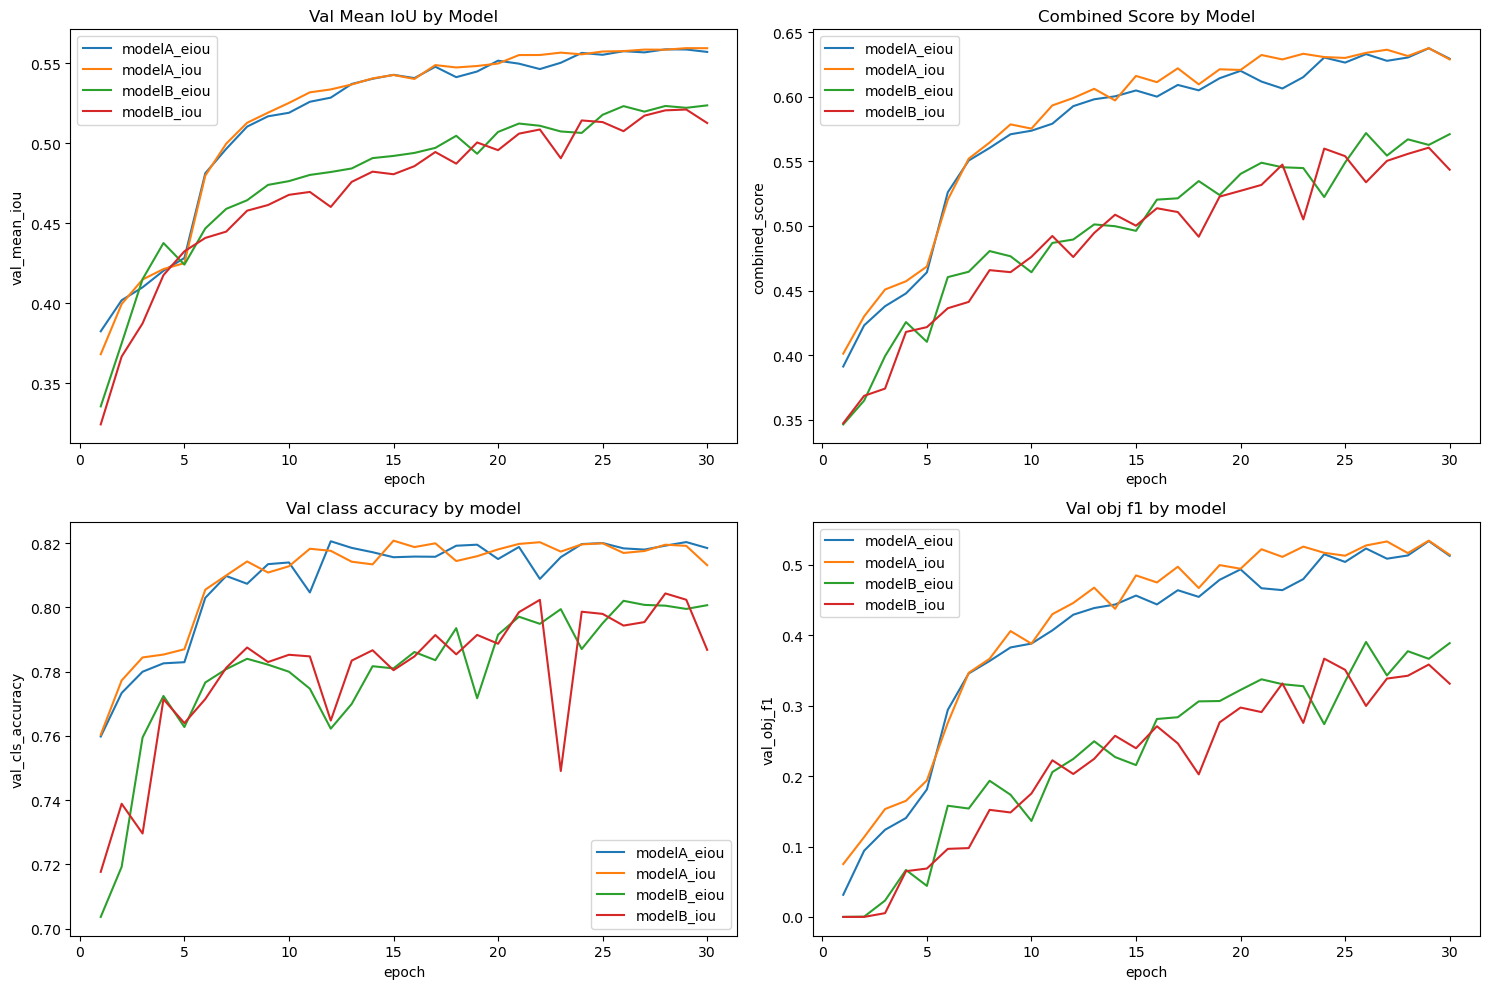

In [82]:
# comparing all 4 real runs' training curves side by side
fig, ax = plt.subplots(2,2, figsize=(15,10))
for name in checkpoints_df.model_name.unique():
    data = checkpoints_df[checkpoints_df['model_name'] == name]
    sns.lineplot(data = data, x = 'epoch', y = 'val_mean_iou', label = name, ax = ax[0,0])
    sns.lineplot(data = data, x = 'epoch', y = 'combined_score', label = name, ax = ax[0,1])
    sns.lineplot(data = data, x = 'epoch', y = 'val_cls_accuracy', label = name, ax = ax[1,0])
    sns.lineplot(data = data, x = 'epoch', y = 'val_obj_f1', label = name, ax = ax[1,1])
    
ax[0,0].set_title('Val Mean IoU by Model')
ax[0,1].set_title('Combined Score by Model')
ax[1,0].set_title('Val class accuracy by model')
ax[1,1].set_title('Val obj f1 by model')

plt.tight_layout()
plt.show()

In [83]:
# per-run diagnostic plots: train vs val loss curves, plus val metrics
import matplotlib.pyplot as plt

def plot_run_diagnostics(df, run_name):
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    fig.suptitle(f"{run_name} — diagnostics", fontsize=14)

    ax = axes[0, 0]
    ax.plot(df["epoch"], df["train_box_loss"], label="train")
    ax.plot(df["epoch"], df["val_box_loss"], label="val")
    ax.set_title("box_loss"); ax.set_xlabel("epoch"); ax.legend()

    ax = axes[0, 1]
    ax.plot(df["epoch"], df["train_cls_loss"], label="train")
    ax.plot(df["epoch"], df["val_cls_loss"], label="val")
    ax.set_title("cls_loss"); ax.set_xlabel("epoch"); ax.legend()

    ax = axes[1, 0]
    ax.plot(df["epoch"], df["train_obj_focal_loss"], label="train")
    ax.plot(df["epoch"], df["val_obj_focal_loss"], label="val")
    ax.set_title("obj_focal_loss"); ax.set_xlabel("epoch"); ax.legend()


    ax = axes[1, 1]
    ax.plot(df["epoch"], df["val_obj_precision"], label="precision")
    ax.plot(df["epoch"], df["val_obj_recall"], label="recall")
    ax.set_title("objectness precision vs recall"); ax.set_xlabel("epoch")
    ax.legend()

    plt.tight_layout()
    plt.show()

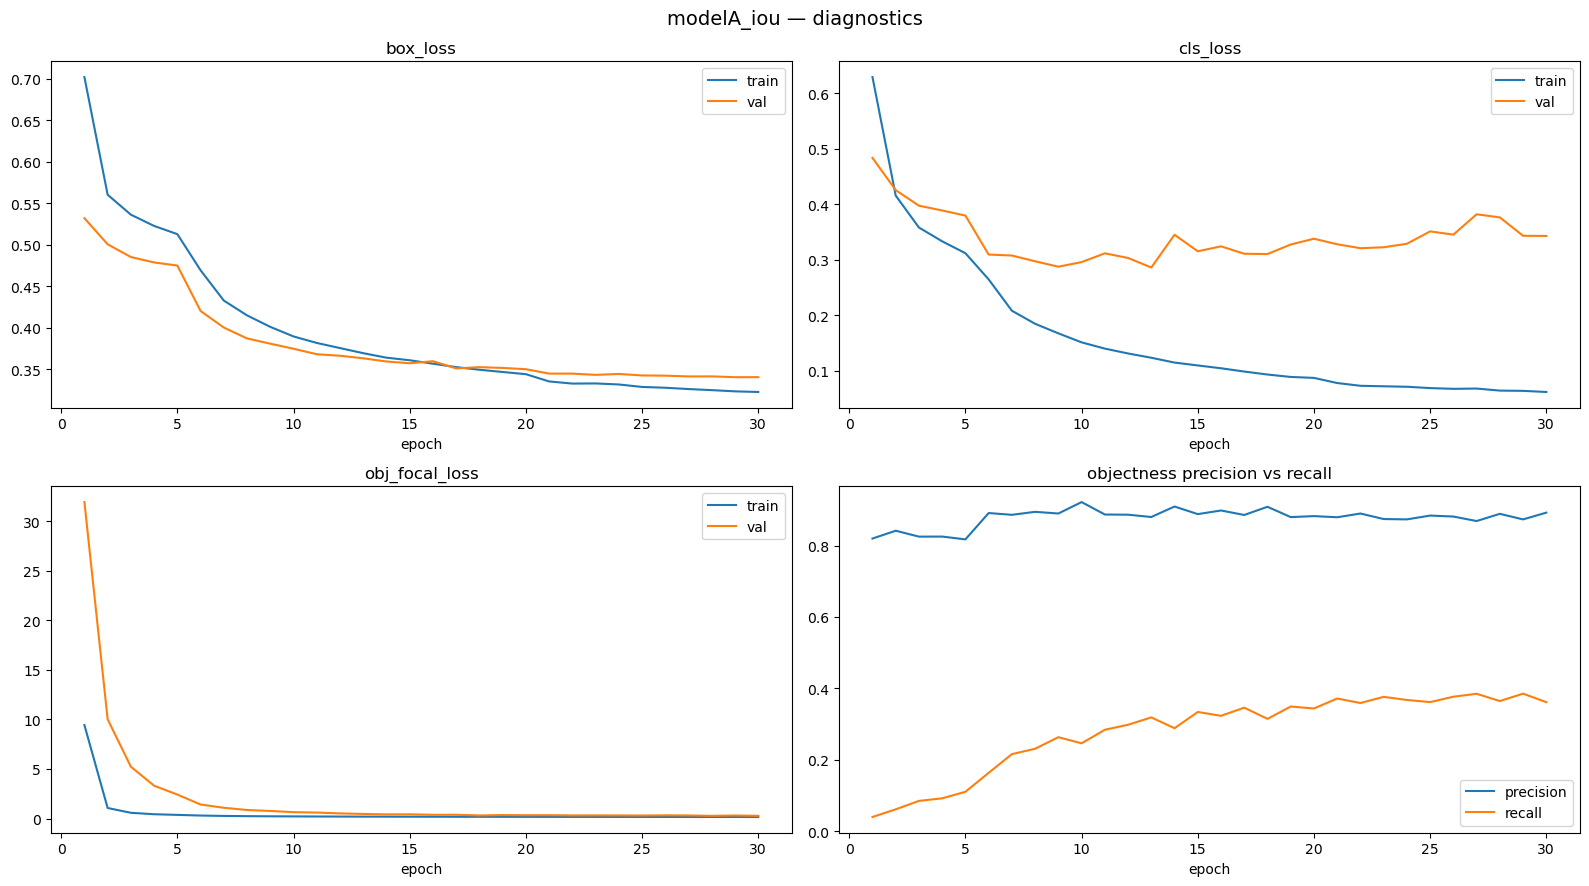

In [84]:
# example- modelA_iou's own diagnostics
plot_run_diagnostics(checkpoints_df[checkpoints_df['model_name'] == 'modelA_iou'], 'modelA_iou')

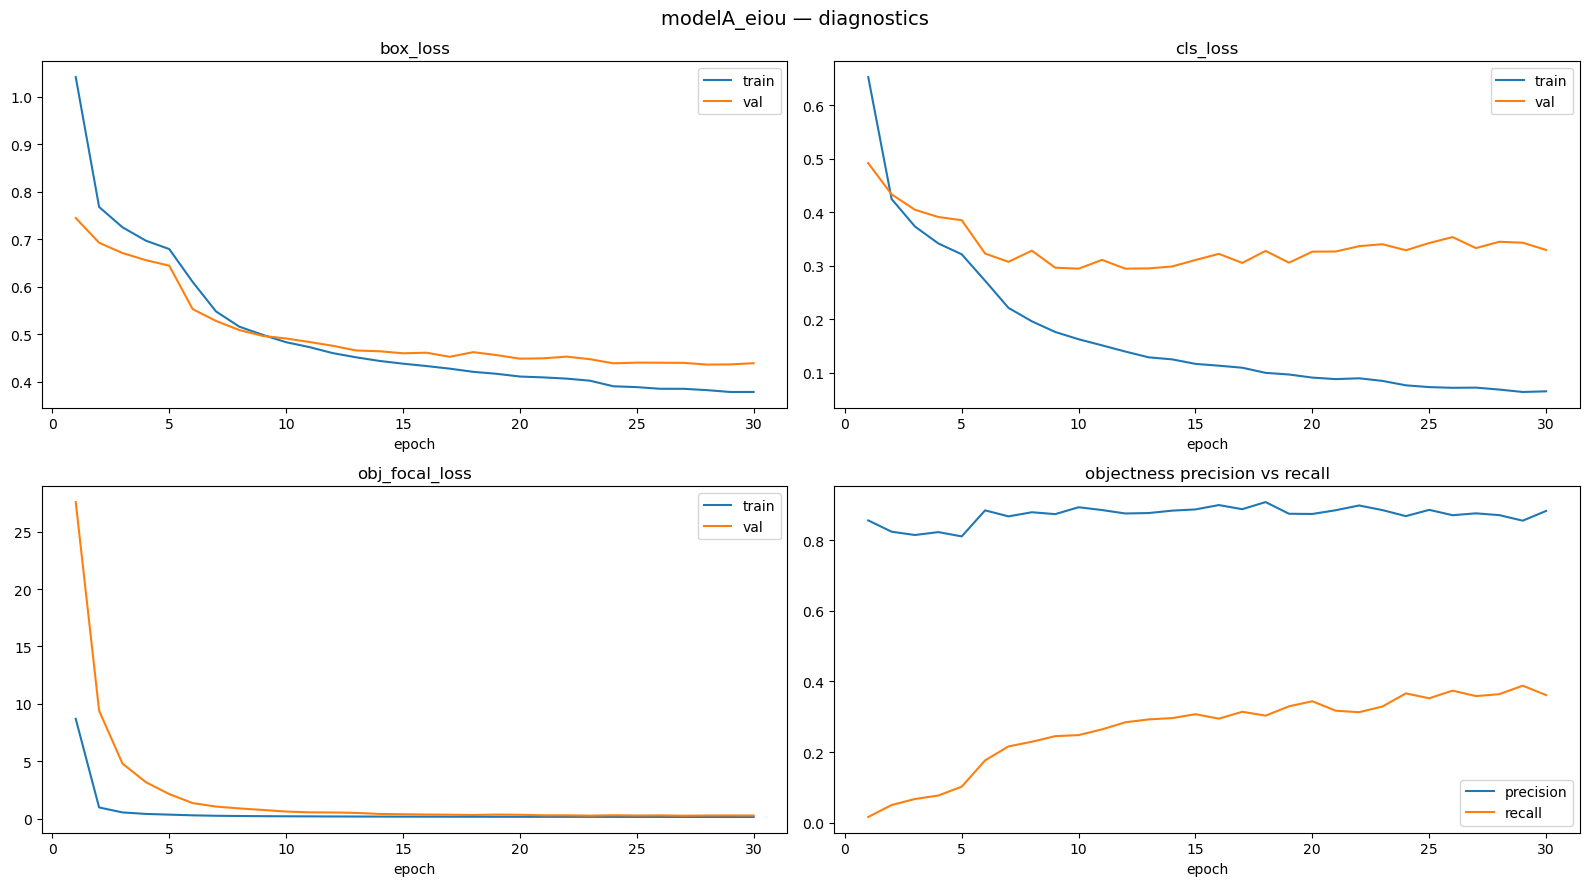

In [85]:
plot_run_diagnostics(checkpoints_df[checkpoints_df['model_name'] == 'modelA_eiou'], 'modelA_eiou')

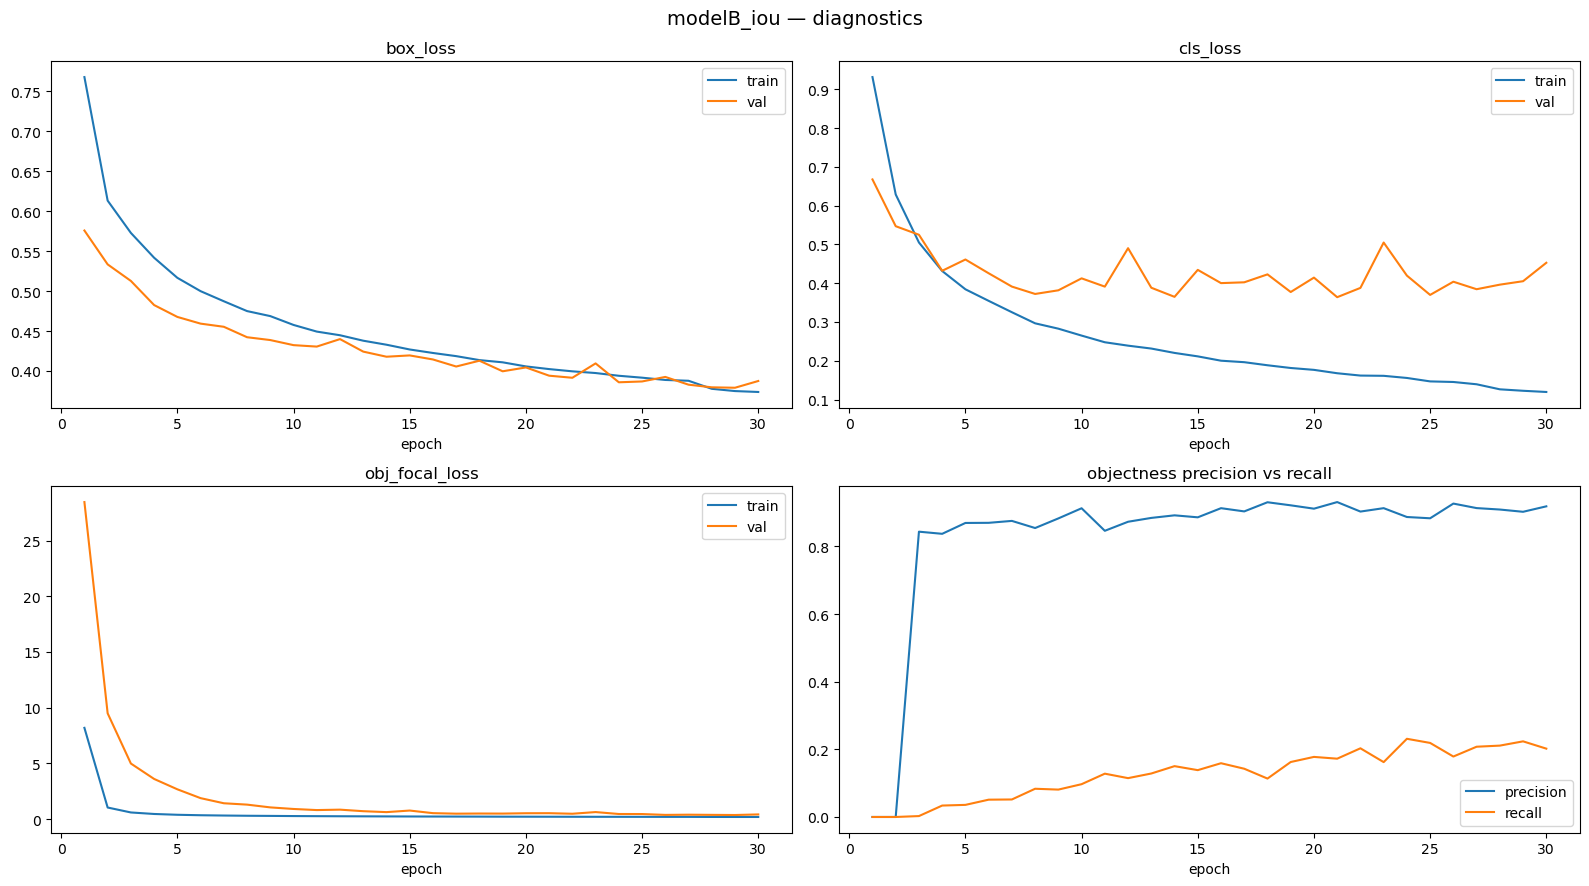

In [86]:
plot_run_diagnostics(checkpoints_df[checkpoints_df['model_name'] == 'modelB_iou'], 'modelB_iou')

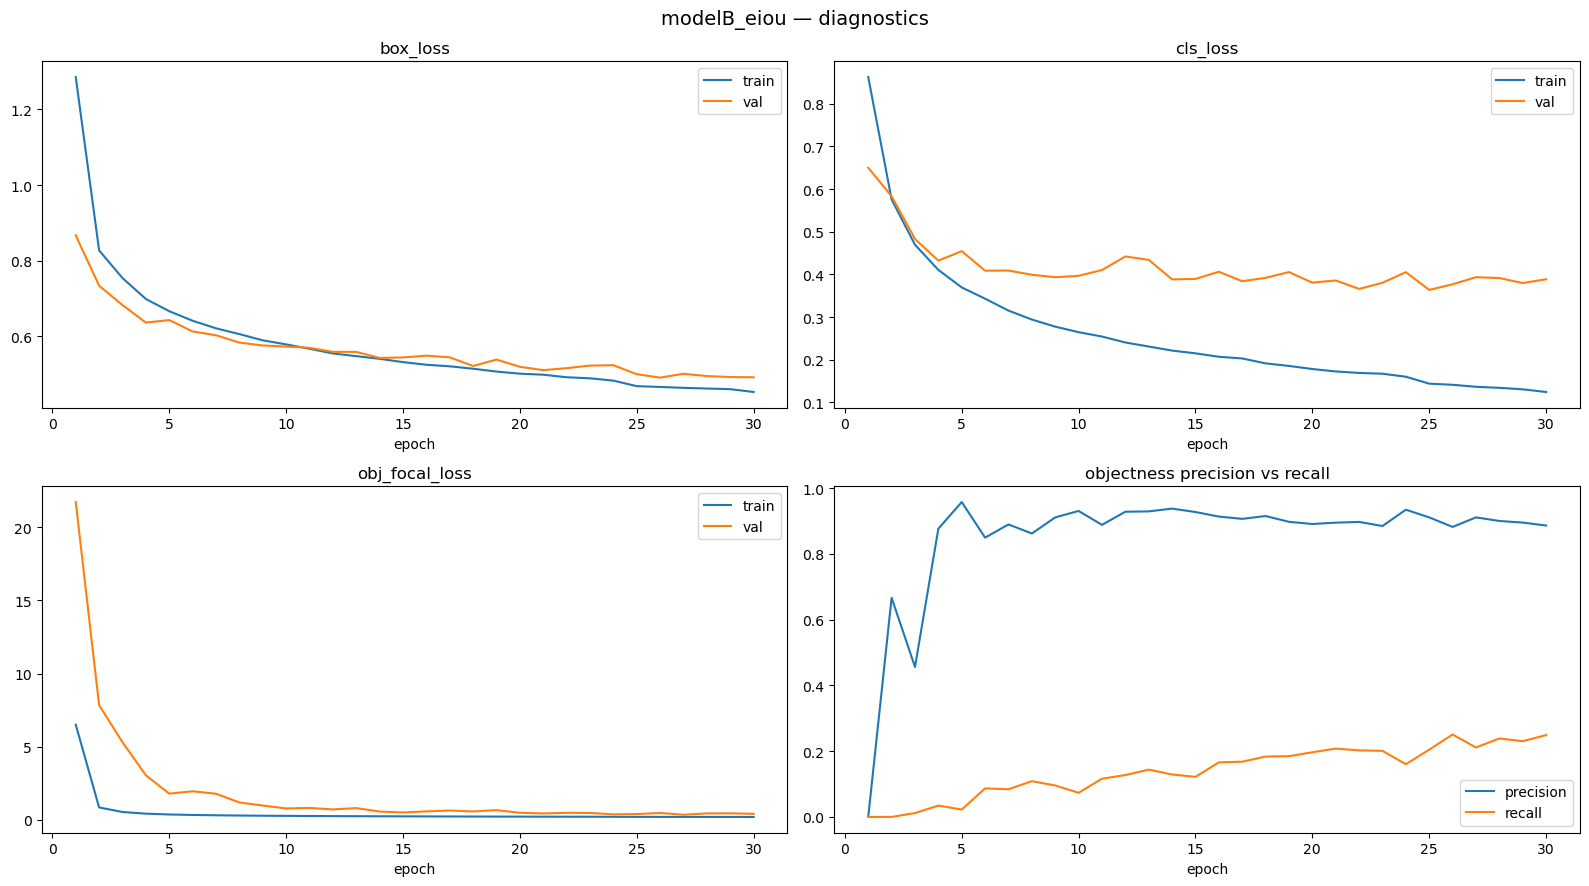

In [87]:
plot_run_diagnostics(checkpoints_df[checkpoints_df['model_name'] == 'modelB_eiou'], 'modelB_eiou')

# 11. Decoding Predictions, NMS & Matching

In [84]:
# picking the real device for inference
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [85]:
# instantiating the model arch
model = DrivingDetector(pretrained=True)

# loading the saved checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load("capstone_python_files/checkpoints/modelA_iou_best.pt", map_location=device)

# loading the weights onto the model
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

DrivingDetector(
  (backbone_body): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

In [86]:
# loading the test dataset using the dataset class we created

test_data = DrivingDetectionDataset('test', augment=False, need_boxes=True)
print(f'No of images in test dataset: {len(test_data)}')

No of images in test dataset: 1373


Number of boxes from test image: 13


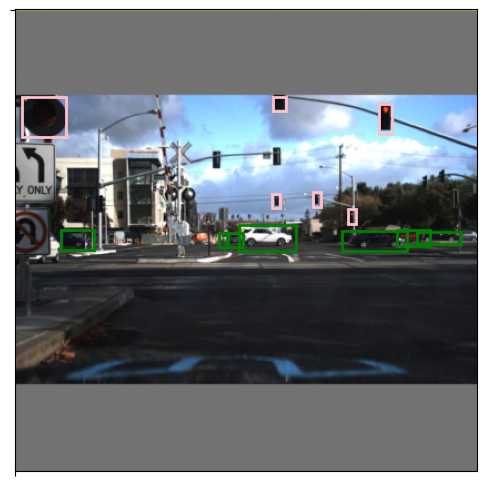

In [87]:
# one real test image, with its real ground-truth boxes
img_tensor, target, actual_boxes = test_data[0]
print(f'Number of boxes from test image: {len(actual_boxes)}')
show_image(unnormalize(img_tensor), actual_boxes, grid_size=0)

In [88]:
# testing model on one test image

img_batch = img_tensor.unsqueeze(0).to(device) #model expects images of size(batch, channel, width, height)

with torch.no_grad():
    raw_output = model(img_batch)
print('Model output shape for one image:', raw_output.shape)

Model output shape for one image: torch.Size([1, 26, 26, 4, 10])


In [89]:
# turns the raw (26,26,4,10) grid output into real (box, class, confidence) detections
def decode_predictions(raw_output, confidence_thershold = 0.3):

    raw_output = raw_output.squeeze(0)
    
    # boolean mask to compare with threshold
    obj_mask = raw_output[..., 0] > confidence_thershold
    survivors =raw_output[obj_mask]

    indices = torch.nonzero(obj_mask)

    row = indices[:, 0]
    col = indices[:, 1]
    
    confidence = survivors[:, 0]
    cx = survivors[:,1]
    cy = survivors[:,2]
    w = survivors[:,3]
    h = survivors[:,4]
    cls_logits = survivors[:, 5: ]
    predlabel = torch.argmax(cls_logits, axis=1)
    
    abs_cx = (col + cx) / 26
    abs_cy = (row + cy) / 26
    
    box = torch.stack([abs_cx, abs_cy, w, h], dim = 1)
    return box, predlabel, confidence

In [90]:
# decoding this one real test image's raw model output
box, predlabel, confidence = decode_predictions(raw_output.squeeze(0))

# how many raw detections survived the confidence threshold
print(f'Number of boxes from model: {len(box)}')

Number of boxes from model: 20


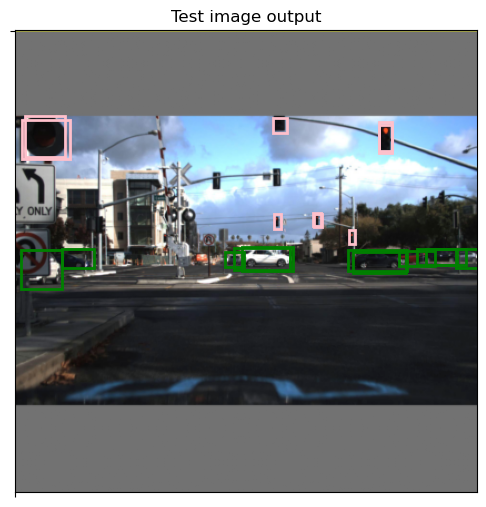

In [91]:
# plotting every surviving raw detection, before NMS
show_image(unnormalize(img_tensor), boxes=torch.column_stack((predlabel, box)).cpu().numpy(), title='Test image output', grid_size=0)

In [92]:
# greedy NMS  keeps the highest-confidence box, suppresses overlapping duplicates
def nms(box, predlabel, confidence, suppress_thresh = 0.4):
    # sorting by the confidence
    order = torch.argsort(confidence, descending=True)
    box = box[order]
    predlabel = predlabel[order]
    confidence = confidence[order]

    # pairwwise iou computation
    iou_matrix = batch_iou(box.unsqueeze(1), box.unsqueeze(0))

    # nms suppressing
    suppressed = torch.zeros(box.shape[0], dtype=torch.bool, device=box.device)
    keep = []
    
    for i in range(0, box.shape[0]):
        if suppressed[i] == False:
            keep.append(i)
            targets = torch.nonzero(iou_matrix[i,i+1:] > suppress_thresh, as_tuple=True)[0]
            targets = targets + i + 1
            suppressed[targets] = True

    # filtering only for the indices in keep
    keep_idx = torch.tensor(keep, dtype=torch.long, device=box.device)
    final_box = box[keep_idx]
    final_predlabel = predlabel[keep_idx]
    final_confidence = confidence[keep_idx]

    return final_box, final_predlabel, final_confidence

Number of boxes from test image: 14


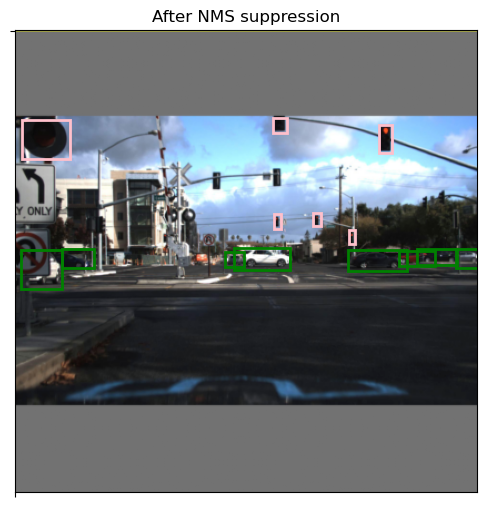

In [93]:
# after NMS - duplicates around the same real object collapsed down to one
final_box, final_predlabel, final_confidence = nms(box, predlabel, confidence)
print(f'Number of boxes from test image: {len(final_box)}')

show_image(unnormalize(img_tensor), boxes=torch.column_stack((final_predlabel, final_box)).cpu().numpy(), title='After NMS suppression', grid_size=0)

In [94]:
# greedy matching: pairs each prediction to its best still-unclaimed ground-truth box
def match_predictions(final_box, final_predlabel, actual_boxes):

    if len(actual_boxes) == 0:
        return [], [], final_box.shape[0], 0

    # converting actual boxes into tensors
    gt_boxes = torch.tensor(actual_boxes, device=device)
    gt_class = gt_boxes[..., 0]
    gt_box = gt_boxes[..., 1:].to(device)
        
    match_threshold = 0.5
    gt_used = torch.zeros(gt_box.shape[0], dtype=torch.bool, device=device)  # sized to M (ground truths), not N

    matched_true = []   # real class, for each successfully matched detection
    matched_pred = []   # predicted class, for the same matched detection
    n_false_positive = 0   # predictions that never found a real match

    match_matrix = batch_iou(final_box.unsqueeze(1), gt_box.unsqueeze(0))

    for i in range(match_matrix.shape[0]):          # walk predictions, already confidence-sorted
        row = match_matrix[i].clone()                # this prediction's IoU vs. all 3 ground truths
        row[gt_used] = -1                             # hide already-claimed ground truths from the max
        best_iou, best_idx = row.max(dim=0)
    
        if best_iou > match_threshold:
            matched_true.append(gt_class[best_idx].long().item())
            matched_pred.append(final_predlabel[i].item())
            gt_used[best_idx] = True                  # claim it — no later prediction can reuse it
        else:
            n_false_positive += 1                      # a detection with no real object nearby
    
    n_false_negative = (~gt_used).sum().item()          # real objects nobody ever claimed
    
    return matched_true, matched_pred, n_false_positive, n_false_negative

In [95]:
# how many of this image's predictions were real matches, false positives, or missed objects
matched_true, matched_pred, n_fp, n_fn = match_predictions(final_box, final_predlabel, actual_boxes)
print(len(matched_true), n_fp, n_fn)

12 2 1


# 12. Full Test-Set Evaluation

running the same decode -> nms -> match pipeline across every image in the real held-out test set, for all 4 models, accumulating a confusion matrix + detection-level tp/fp/fn per model

In [96]:
# runs the full decode->nms->match pipeline across one checkpoint's entire test-set pass
def evaluate_checkpoint(model_checkpoint, pretrained):

    # instantiating the model and loading in the weights
    model =  DrivingDetector(pretrained = pretrained)
    checkpoint_path = "capstone_python_files/checkpoints/" + model_checkpoint + ".pt"
    checkpoint = torch.load(checkpoint_path, map_location = device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    confusion = torch.zeros(5,5, dtype = torch.long)
    total_tp = total_fp = total_fn = 0

    t0 = time.time()
    
    # looping over all test images
    for idx in range(len(test_data)):
        elapsed = time.time() - t0
        print(f'\r{model_checkpoint} -> {idx+1}/{len(test_data)} test images processed - {elapsed:.0f}s', end = '', flush=True)

        # getting the image and the actual labels
        img_tensor, target, actual_boxes = test_data[idx]    
    
        # passing the image through the model
        img_batch = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            raw_output = model(img_batch)
    
        # decoding predictions
        box, predlabel, confidence = decode_predictions(raw_output)
    
        # suppressing overlapping boxes
        final_box, final_predlabel, final_confidence = nms(box, predlabel, confidence)
    
        # matching with actual boxes
        matched_true, matched_pred, n_fp, n_fn = match_predictions(final_box, final_predlabel, actual_boxes)
    
        # getting detection level cm
        total_tp += len(matched_true)
        total_fp += n_fp
        total_fn += n_fn
    
        # computing per class metrics
        for true_c, pred_c in zip(matched_true, matched_pred):
            confusion[true_c][pred_c] += 1
    
    total_elapsed = time.time() - t0
    print(f'\r{model_checkpoint} -> {len(test_data)}/{len(test_data)} test images processed - {total_elapsed:.0f}s done')

    return confusion, total_tp, total_fp, total_fn

In [97]:
# the 4 real trained checkpoints -- file name + whether that run used a pretrained backbone
checkpoints = {
    "modelA_iou":  ("modelA_iou_best", True),
    "modelA_eiou": ("modelA_eiou_best", True),
    "modelB_iou":  ("modelB_iou_best", False),
    "modelB_eiou": ("modelB_eiou_best", False),
}

In [98]:
# actually running all 4 checkpoints now -- this is the real, full test-set evaluation
results = {}

for name, (model_checkpoint, pretrained) in checkpoints.items():
    results[name] = evaluate_checkpoint(model_checkpoint, pretrained)

modelA_iou_best -> 1373/1373 test images processed - 110s done
modelA_eiou_best -> 1373/1373 test images processed - 96s done
modelB_iou_best -> 1373/1373 test images processed - 101s done
modelB_eiou_best -> 1373/1373 test images processed - 100s done


In [99]:
# building a long-format dataframe of detection-level precision/recall/f1, one row per model per metric
rows = []
for name, (confusion, tp, fp, fn) in results.items():
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)
    rows.append({'model': name, 'metric': 'precision', 'value': precision})
    rows.append({'model': name, 'metric': 'recall', 'value': recall})
    rows.append({'model': name, 'metric': 'f1', 'value': f1})
results_df = pd.DataFrame(rows)
results_df

,model,metric,value
0,modelA_iou,precision,0.611715
1,modelA_iou,recall,0.574046
2,modelA_iou,f1,0.592282
3,modelA_eiou,precision,0.595442
4,modelA_eiou,recall,0.572655
5,modelA_eiou,f1,0.583826
6,modelB_iou,precision,0.577838
7,modelB_iou,recall,0.470486
8,modelB_iou,f1,0.518665
9,modelB_eiou,precision,0.499368


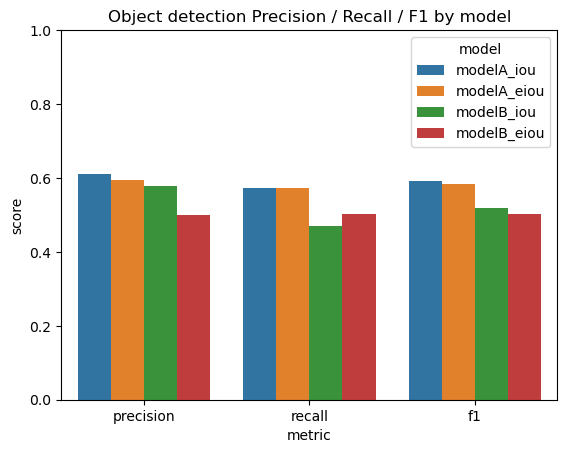

In [100]:
# plotting detection-level precision/recall/f1 for all 4 models side by side
sns.barplot(data=results_df, x='metric', y='value', hue='model')
plt.title('Object detection Precision / Recall / F1 by model')
plt.ylim(0, 1)
plt.ylabel('score')
plt.show()

In [101]:
# per-class f1 by model
rows = []

for name, (confusion, tp, fp, fn) in results.items():
    TP = confusion.diagonal()
    FP = confusion.sum(dim=0) - TP
    FN = confusion.sum(dim=1) - TP
    
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)
    for class_name, p, r, f in zip(NEW_CLASS_NAMES, precision, recall, f1):
        rows.append({'model': name, 'class': class_name, 'precision': p.item(), 'recall': r.item(), 'f1_score': f.item()})
results_df = pd.DataFrame(rows)
results_df

,model,class,precision,recall,f1_score
0,modelA_iou,biker,0.833333,0.277778,0.416667
1,modelA_iou,car,0.983758,0.989299,0.986521
2,modelA_iou,pedestrian,0.470588,0.923077,0.623377
3,modelA_iou,truck,0.340426,0.235294,0.278261
4,modelA_iou,trafficLight,1.000000,1.000000,1.000000
5,modelA_eiou,biker,0.916667,0.275000,0.423077
6,modelA_eiou,car,0.982043,0.988701,0.985360
7,modelA_eiou,pedestrian,0.542373,0.969697,0.695652
8,modelA_eiou,truck,0.270833,0.185714,0.220339
9,modelA_eiou,trafficLight,1.000000,1.000000,1.000000


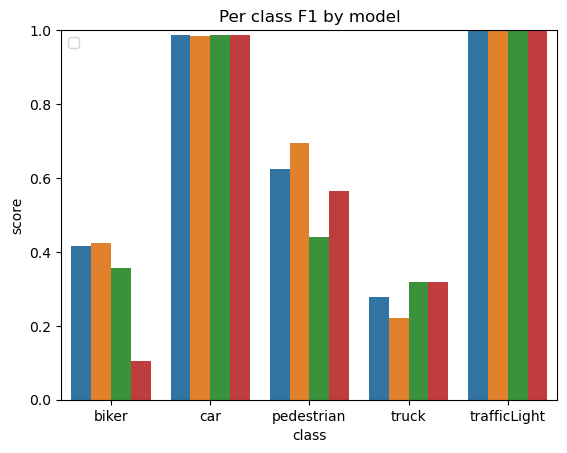

In [102]:
# plotting per-class f1 for all 4 models side by side
sns.barplot(data=results_df, x='class', y='f1_score', hue='model')
plt.title('Per class F1 by model')
plt.ylim(0, 1)
plt.ylabel('score')
plt.legend('')
plt.show()

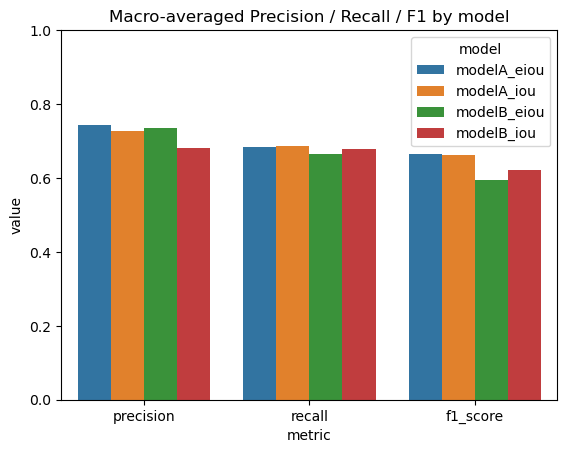

In [103]:
# plotting macro-averaged precision/recall/f1 for all 4 models
macro_df = results_df.groupby(['model'])[['precision', 'recall', 'f1_score']].mean()
macro_long = macro_df.reset_index().melt(id_vars='model', var_name='metric', value_name='value')

# plt.figure(figsize=(8, 5))
sns.barplot(data=macro_long, x='metric', y='value', hue='model')
plt.title('Macro-averaged Precision / Recall / F1 by model')
plt.ylim(0, 1)
plt.show()

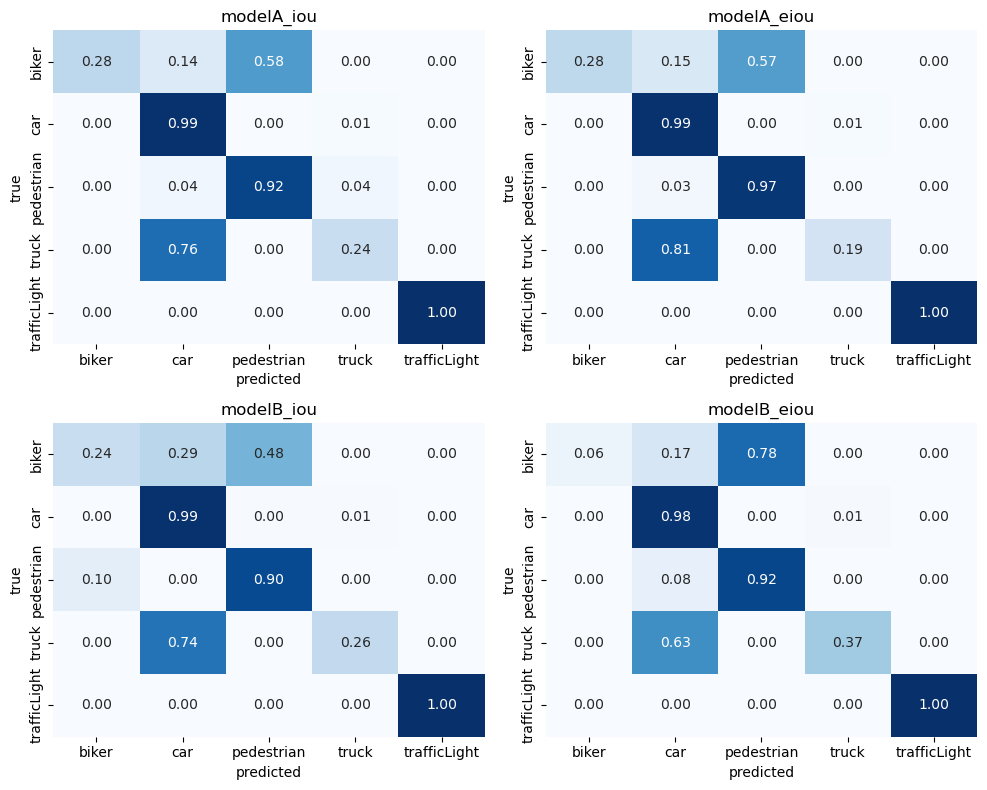

In [104]:
# side-by-side, row-normalized confusion matrix heatmaps for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, (confusion, tp, fp, fn)) in zip(axes, results.items()):
    cm = confusion.cpu().numpy()
    cm_normalized = cm / cm.sum(axis=1, keepdims=True)   # row-normalize: each row sums to 1

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=NEW_CLASS_NAMES, yticklabels=NEW_CLASS_NAMES,
                vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')

plt.tight_layout()
plt.show()

# 13. Real-Time Video Demo

Used raw html and Flask to deploy this model. It shows a livestream of the model with real time object finding and annotation.